Setup & Model Loading

### 1. Setup + Load Semua Model + Data
**Tujuan:** Memuat 5 model terlatih (3 classifier + 2 RUL predictor) dan semua split artifacts untuk evaluasi komprehensif.  
**Input:** models/ml_track/{rf,xgb,lgbm}_classifier.pkl, models/ml_track/xgb_regressor.pkl, models/dl_track/lstm_rul_best_v2.keras, semua split artifacts  
**Output:** 5 model object siap evaluasi  in-memory  
**Catatan:** Pastikan semua model sudah ada di direktori yang benar sebelum menjalankan notebook ini.  


In [1]:
# FASE 9 — Cell 1: Setup & Load Semua Artifacts
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json
from pathlib import Path

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score,
    recall_score, mean_absolute_error,
    mean_squared_error, r2_score,
    ConfusionMatrixDisplay, roc_curve, auc,
)
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import load_model

warnings.filterwarnings("ignore")

# ─── PATH SETUP ────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import (
    DATA_PROCESSED_DIR, MODELS_ML_DIR, MODELS_DL_DIR,
    MODELS_FINAL_DIR, GLOBAL_SEED, LABEL_MAP,
)

np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)

SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  FASE 9 — EVALUATION, CALIBRATION & MODEL SELECTION")
print(SEP)

# ─── LOAD CLASSIFIER DATA ──────────────────────────────────
print("\n  [1/4] Memuat data klasifikasi...")
X_val_clf  = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val_clf  = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test_clf = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test_clf = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()
print("  OK — Classifier data loaded.")

# ─── LOAD RUL DATA ─────────────────────────────────────────
print("\n  [2/4] Memuat data RUL...")
X_val_rul  = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_rul.parquet")
y_val_rul  = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_rul.parquet").squeeze()
X_test_rul = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_rul.parquet")
y_test_rul = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_rul.parquet").squeeze()

df_ssbs = (
    pd.read_parquet(DATA_PROCESSED_DIR / "df_ssbs_rul.parquet")
    .sort_values(["machine_id", "timestamp"])
    .reset_index(drop=True)
)

VAL_MACHINES  = ["M-15", "M-16", "M-17"]
TEST_MACHINES = ["M-18", "M-19", "M-20"]

mask_val  = (df_ssbs[df_ssbs["machine_id"].isin(VAL_MACHINES)]
             ["health_label_encoded"].isin([1, 2]).values)
mask_test = (df_ssbs[df_ssbs["machine_id"].isin(TEST_MACHINES)]
             ["health_label_encoded"].isin([1, 2]).values)

X_val_rul_f  = X_val_rul[mask_val].reset_index(drop=True)
y_val_rul_f  = y_val_rul[mask_val].reset_index(drop=True)
X_test_rul_f = X_test_rul[mask_test].reset_index(drop=True)
y_test_rul_f = y_test_rul[mask_test].reset_index(drop=True)
print("  OK — RUL data loaded & filtered (WARNING+CRITICAL only).")

# ─── SEQUENCE PREPARATION UNTUK LSTM ──────────────────────
SEQ_LEN = 24

def create_sequences(X, y, seq_len):
    seqs, tgts = [], []
    for i in range(seq_len, len(X)):
        seqs.append(X[i - seq_len:i])
        tgts.append(y[i])
    return np.array(seqs), np.array(tgts)

X_val_seq,  y_val_seq  = create_sequences(
    X_val_rul_f.values,  y_val_rul_f.values,  SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(
    X_test_rul_f.values, y_test_rul_f.values, SEQ_LEN)
print("  OK — Sequences created.")

# ─── LOAD MODELS ───────────────────────────────────────────
print("\n  [3/4] Memuat semua model...")
rf_model   = joblib.load(MODELS_ML_DIR / "rf_classifier.pkl")
xgb_model  = joblib.load(MODELS_ML_DIR / "xgb_classifier.pkl")
lgbm_model = joblib.load(MODELS_ML_DIR / "lgbm_classifier.pkl")
xgb_rul    = joblib.load(MODELS_ML_DIR / "xgb_regressor.pkl")
lstm_model  = load_model(str(MODELS_DL_DIR / "lstm_rul_best_v2.keras"))

XGB_CLF_THRESHOLD = 0.60
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}   # {0: 'HEALTHY', 1: 'WARNING', 2: 'CRITICAL'}
CLASS_NAMES = ["HEALTHY", "WARNING", "CRITICAL"]

print("  OK — Semua model loaded.")

# ─── KONFIRMASI TABEL MODEL ────────────────────────────────
print(f"\n{sep}")
print("  MODEL REGISTRY")
print(sep)
model_registry = [
    ("Random Forest",      "CLF", "rf_classifier.pkl",      rf_model),
    ("XGBoost Clf",        "CLF", "xgb_classifier.pkl",     xgb_model),
    ("LightGBM Clf",       "CLF", "lgbm_classifier.pkl",    lgbm_model),
    ("XGBoost Regressor",  "RUL", "xgb_regressor.pkl",      xgb_rul),
    ("LSTM V2",            "RUL", "lstm_rul_best_v2.keras",  lstm_model),
]
print(f"\n  {'Model':<22} {'Type':<6} {'File':<28} {'Status'}")
print(f"  {'-'*65}")
for name, mtype, fname, _ in model_registry:
    print(f"  {name:<22} {mtype:<6} {fname:<28} ✅")

# ─── KONFIRMASI TABEL DATA ─────────────────────────────────
print(f"\n{sep}")
print("  DATA SHAPES")
print(sep)
datasets = [
    ("X_val_clf",   X_val_clf),
    ("X_test_clf",  X_test_clf),
    ("X_val_rul_f", X_val_rul_f),
    ("X_test_rul_f",X_test_rul_f),
    ("X_val_seq",   X_val_seq),
    ("X_test_seq",  X_test_seq),
]
print(f"\n  {'Dataset':<16} {'Shape'}")
print(f"  {'-'*35}")
for name, arr in datasets:
    shape = arr.shape if hasattr(arr, "shape") else (len(arr),)
    print(f"  {name:<16} {str(shape)}")

print(f"\n  XGB_CLF_THRESHOLD  : {XGB_CLF_THRESHOLD}")
print(f"  GLOBAL_SEED        : {GLOBAL_SEED}")
print(f"  SEQ_LEN (LSTM)     : {SEQ_LEN}")
print(f"  LABEL_MAP          : {LABEL_MAP}")

print(f"\n{SEP}")
print("  ✅ FASE 9 SETUP COMPLETE — Semua artifacts loaded")
print(f"  [4/4] Lanjut ke Cell 2 untuk evaluasi Model 1 (Classifier).")
print(SEP)



  FASE 9 — EVALUATION, CALIBRATION & MODEL SELECTION

  [1/4] Memuat data klasifikasi...
  OK — Classifier data loaded.

  [2/4] Memuat data RUL...
  OK — RUL data loaded & filtered (WARNING+CRITICAL only).
  OK — Sequences created.

  [3/4] Memuat semua model...

  OK — Semua model loaded.

-----------------------------------------------------------------
  MODEL REGISTRY
-----------------------------------------------------------------

  Model                  Type   File                         Status
  -----------------------------------------------------------------
  Random Forest          CLF    rf_classifier.pkl            ✅
  XGBoost Clf            CLF    xgb_classifier.pkl           ✅
  LightGBM Clf           CLF    lgbm_classifier.pkl          ✅
  XGBoost Regressor      RUL    xgb_regressor.pkl            ✅
  LSTM V2                RUL    lstm_rul_best_v2.keras       ✅

-----------------------------------------------------------------
  DATA SHAPES
------------------------

Classifier Comprehensive Evaluation

### 2. Evaluasi Komprehensif Classifier (3 Model)
**Tujuan:** Mengevaluasi RF, XGBoost V2+Threshold, dan LightGBM+Threshold pada Test Set dengan metrik bisnis utama: F1, Fatal Error rate, false alarm rate.  
**Input:** 3 classifier models + X_test, y_test  
**Output:** Comprehensive metrics table + Confusion Matrices + Feature Importance Consensus  
**Catatan:** Metrik bisnis kritis: Fatal Error (CRITICALHEALTHY) = 0 untuk SEMUA model. False Alarm Rate terendah: XGBoost. KEPUTUSAN: XGBoost V2 + Threshold(0.60) dipilih sebagai Model 1 Final.  

[TARGET] **Dipakai di:** Paper IEEE Table IV (Final Classifier Comparison) / Slide halaman 19

  FASE 9 — Cell 2: CLASSIFIER COMPREHENSIVE EVALUATION

  [1/7] Generating predictions...
  OK — Semua prediksi berhasil digenerate.

  BAGIAN 2 — COMPREHENSIVE METRICS TABLE

  ───────────────────────────────────────────────────────────────────────────
  TABEL 1 — F1 Score Comparison
  ───────────────────────────────────────────────────────────────────────────
  Model           F1 Val  F1 Test    F1 H (V/T)     F1 W (V/T)     F1 C (V/T)
  ───────────────────────────────────────────────────────────────────────────
  Random Forest   0.9292   0.9914  0.990/1.000   0.811/0.986   0.987/0.989
  XGBoost         0.9894   0.9906  0.999/1.000   0.982/0.986   0.987/0.987
  LightGBM        0.9845   0.9876  1.000/0.998   0.970/0.978   0.984/0.987

  ────────────────────────────────────────────────────────────────────────────────
  TABEL 2 — Precision & Recall (Test Set)
  ────────────────────────────────────────────────────────────────────────────────
  Model            Pr H   Pr W   Pr C   Rc H  

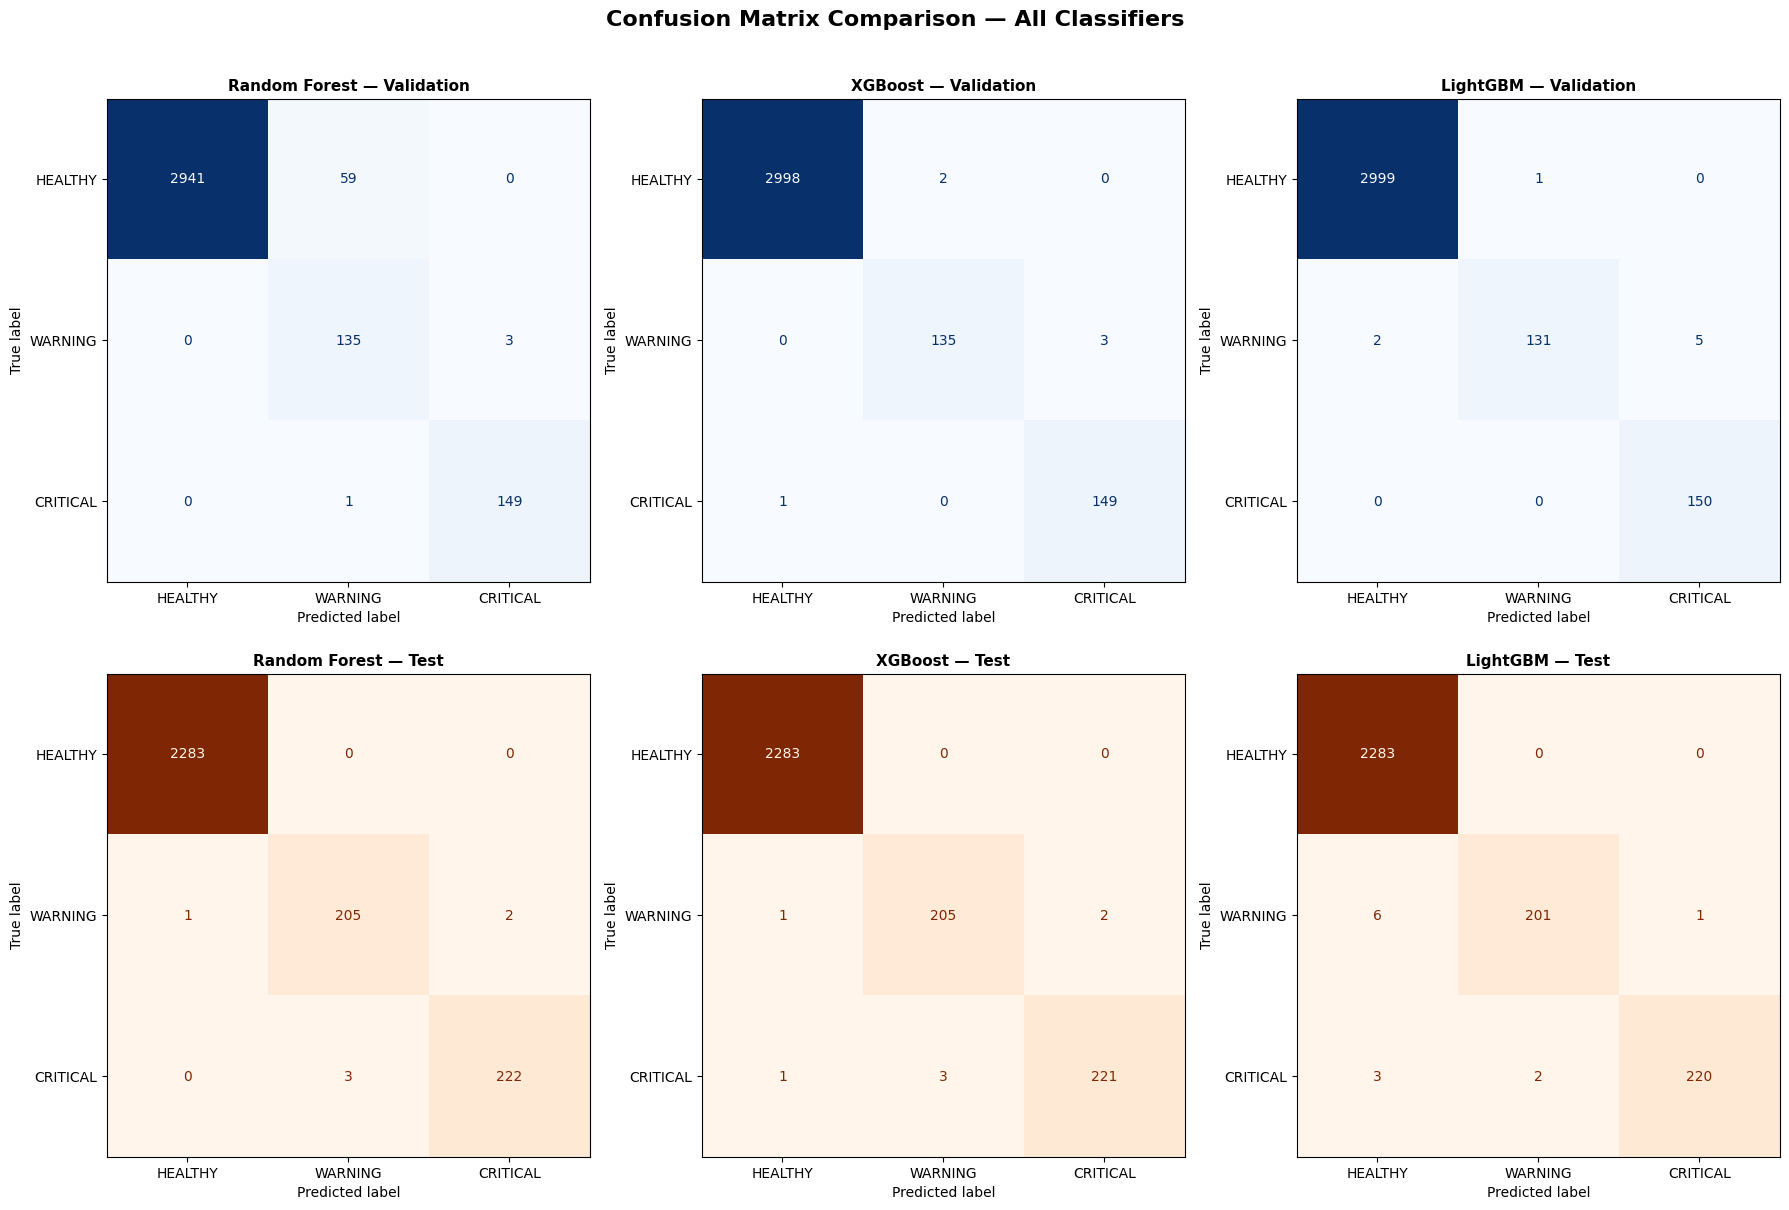

  ✅ Confusion matrices plotted.

  BAGIAN 4 — ROC-AUC CURVE (Test Set — Overlay 3 Model)


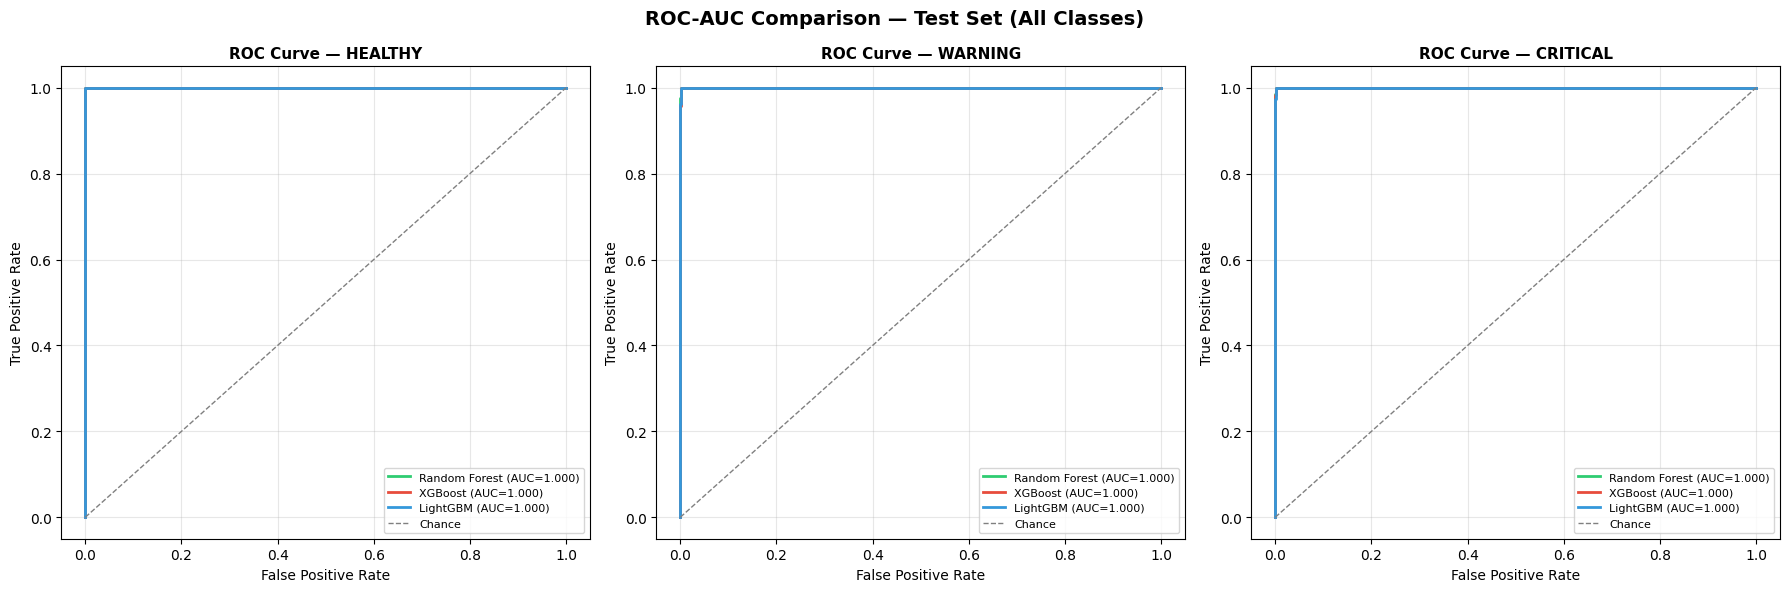

  ✅ ROC-AUC curves plotted.

  BAGIAN 5 — FEATURE IMPORTANCE COMPARISON (Top 15)


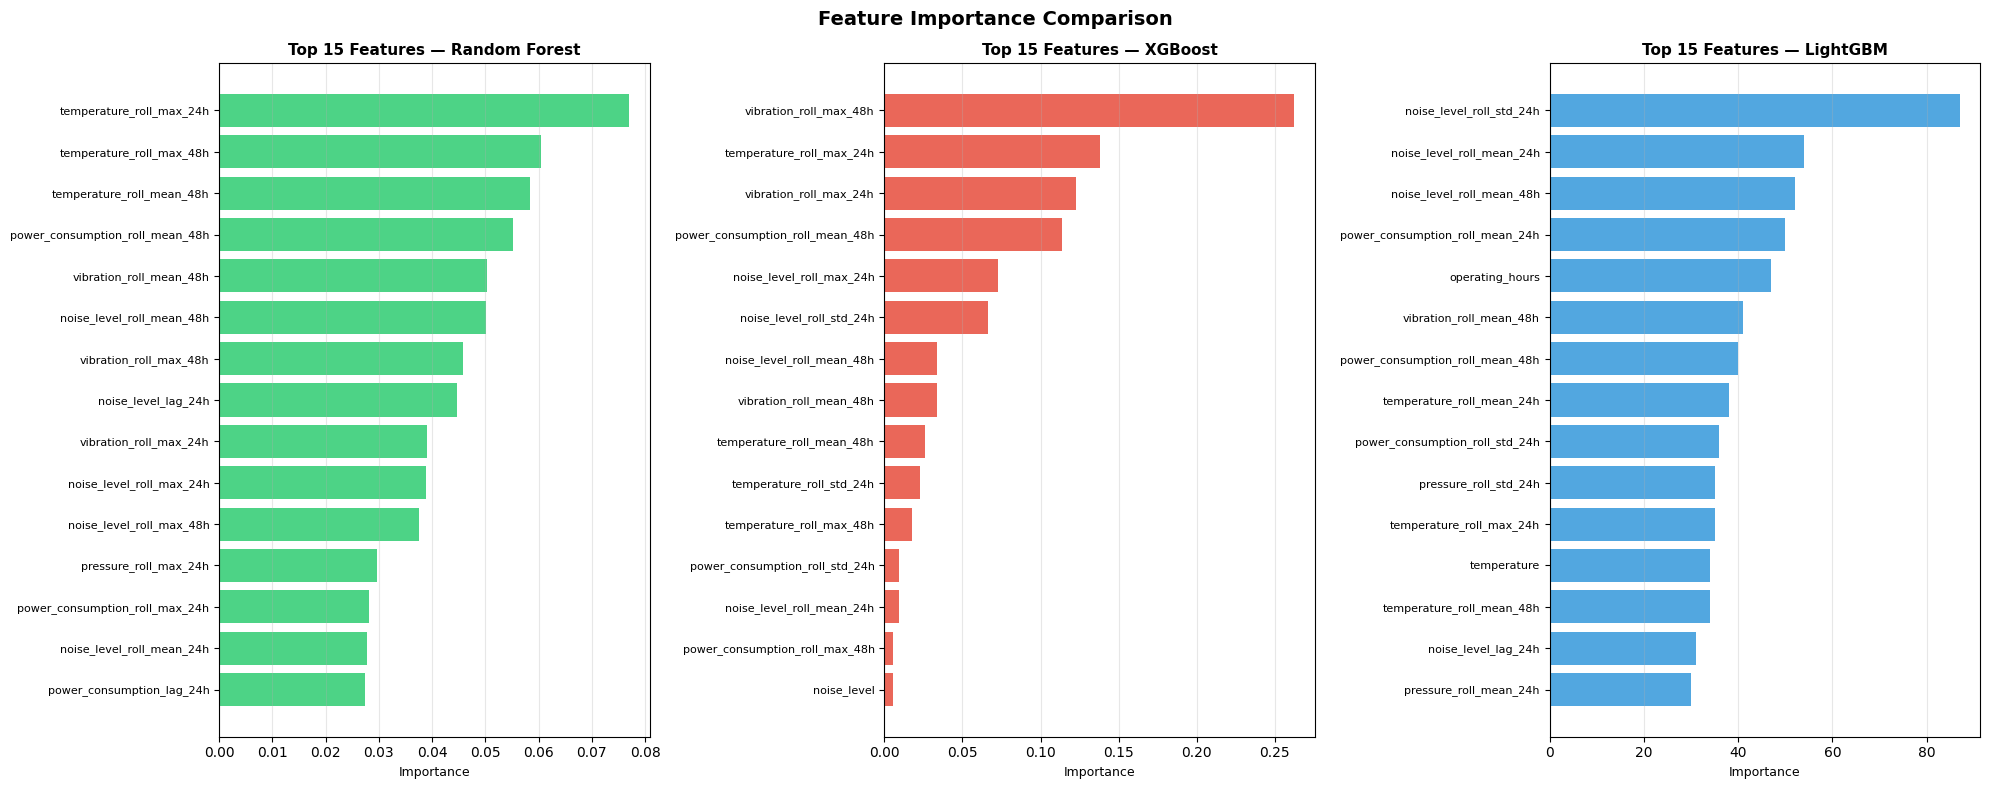


  ───────────────────────────────────────────────────────────────────────────
  TOP FITUR KONSISTEN (muncul di ≥ 2 dari 3 model, Top 15)
  ───────────────────────────────────────────────────────────────────────────

  Feature                                       RF Rank  XGB Rank  LGBM Rank Consensus
  ───────────────────────────────────────────────────────────────────────────────────────
  temperature_roll_max_24h                            1         2         11  ★★★ (3/3)
  noise_level_roll_mean_24h                          14        13          2  ★★★ (3/3)
  temperature_roll_mean_48h                           3         9         13  ★★★ (3/3)
  power_consumption_roll_mean_48h                     4         4          7  ★★★ (3/3)
  vibration_roll_mean_48h                             5         8          6  ★★★ (3/3)
  noise_level_roll_mean_48h                           6         7          3  ★★★ (3/3)
  power_consumption_roll_std_24h                      -        12          9  

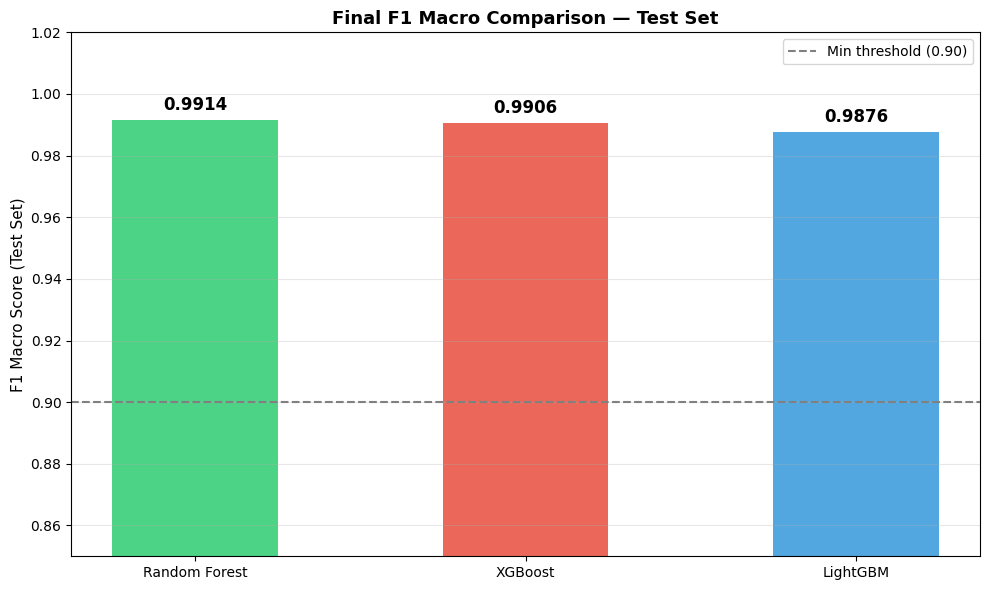


  CLASSIFIER FINAL VERDICT
  Model Terpilih : XGBoost V2 + Threshold (0.6)
  Alasan         :
  1. F1 Macro Val tertinggi (0.9894)
  2. WARNING F1 Val terbaik (0.9818)
  3. Fatal Error = 0 (tidak ada CRITICAL→HEALTHY)
  4. False Alarm terkecil di Val set
  ✅ Cell 2 selesai — lanjut ke Cell 3 (RUL Evaluation).


In [2]:
# FASE 9 — Cell 2: Classifier Evaluation (All 7 Bagian)
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score, accuracy_score

SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  FASE 9 — Cell 2: CLASSIFIER COMPREHENSIVE EVALUATION")
print(SEP)

CLASS_NAMES       = ["HEALTHY", "WARNING", "CRITICAL"]
LGBM_CLF_THRESHOLD = 0.65

# ────────────────────────────────────────────────────────────
# BAGIAN 1 — GENERATE PREDICTIONS
# ────────────────────────────────────────────────────────────
def predict_with_threshold(model, X, threshold):
    proba = model.predict_proba(X)
    preds = []
    for p in proba:
        if   p[2] > 0.50:       preds.append(2)
        elif p[1] > threshold:  preds.append(1)
        else:                   preds.append(0)
    return np.array(preds), proba

print(f"\n  [1/7] Generating predictions...")

rf_val_pred,    rf_val_proba    = rf_model.predict(X_val_clf),  rf_model.predict_proba(X_val_clf)
rf_test_pred,   rf_test_proba   = rf_model.predict(X_test_clf), rf_model.predict_proba(X_test_clf)

xgb_val_pred,   xgb_val_proba   = predict_with_threshold(xgb_model,  X_val_clf,  XGB_CLF_THRESHOLD)
xgb_test_pred,  xgb_test_proba  = predict_with_threshold(xgb_model,  X_test_clf, XGB_CLF_THRESHOLD)

lgbm_val_pred,  lgbm_val_proba  = predict_with_threshold(lgbm_model, X_val_clf,  LGBM_CLF_THRESHOLD)
lgbm_test_pred, lgbm_test_proba = predict_with_threshold(lgbm_model, X_test_clf, LGBM_CLF_THRESHOLD)

print("  OK — Semua prediksi berhasil digenerate.")

# Bundle semua model untuk looping
models_info = [
    ("Random Forest", rf_val_pred,   rf_val_proba,   rf_test_pred,   rf_test_proba),
    ("XGBoost",       xgb_val_pred,  xgb_val_proba,  xgb_test_pred,  xgb_test_proba),
    ("LightGBM",      lgbm_val_pred, lgbm_val_proba, lgbm_test_pred, lgbm_test_proba),
]

# ────────────────────────────────────────────────────────────
# BAGIAN 2 — COMPREHENSIVE METRICS TABLE
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 2 — COMPREHENSIVE METRICS TABLE")
print(SEP)

def safe_f1_per_class(y_true, y_pred, cls_idx):
    return f1_score(y_true, y_pred, labels=[cls_idx], average=None,
                    zero_division=0)[0]

def safe_prec(y_true, y_pred, cls_idx):
    return precision_score(y_true, y_pred, labels=[cls_idx], average=None,
                           zero_division=0)[0]

def safe_rec(y_true, y_pred, cls_idx):
    return recall_score(y_true, y_pred, labels=[cls_idx], average=None,
                        zero_division=0)[0]

def false_alarm_rate(y_true, y_pred, warn_idx=1):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    fp_warn = sum(cm[i, warn_idx] for i in range(len(cm)) if i != warn_idx)
    tn_warn = sum(cm[i, j] for i in range(len(cm)) for j in range(len(cm))
                  if i != warn_idx and j != warn_idx)
    denom = fp_warn + tn_warn
    return fp_warn / denom if denom > 0 else 0.0

def fatal_error_rate(y_true, y_pred, crit_idx=2, healthy_idx=0):
    mask      = (np.array(y_true) == crit_idx)
    n_critical = mask.sum()
    n_fatal    = ((np.array(y_pred)[mask]) == healthy_idx).sum()
    return n_fatal, n_critical

# ── Tabel 1: F1 Score ──
print(f"\n  {'─'*75}")
print("  TABEL 1 — F1 Score Comparison")
print(f"  {'─'*75}")
header = (f"  {'Model':<14}{'F1 Val':>8}{'F1 Test':>9}"
          f"{'F1 H (V/T)':>14}{'F1 W (V/T)':>15}{'F1 C (V/T)':>15}")
print(header)
print(f"  {'─'*75}")

all_metrics = {}
for name, vp, _, tp, _ in models_info:
    f1v = f1_score(y_val_clf,  vp, average="macro", zero_division=0)
    f1t = f1_score(y_test_clf, tp, average="macro", zero_division=0)
    hv  = safe_f1_per_class(y_val_clf, vp, 0);  ht  = safe_f1_per_class(y_test_clf, tp, 0)
    wv  = safe_f1_per_class(y_val_clf, vp, 1);  wt  = safe_f1_per_class(y_test_clf, tp, 1)
    cv  = safe_f1_per_class(y_val_clf, vp, 2);  ct  = safe_f1_per_class(y_test_clf, tp, 2)
    print(f"  {name:<14}{f1v:>8.4f}{f1t:>9.4f}"
          f"  {hv:.3f}/{ht:.3f}   {wv:.3f}/{wt:.3f}   {cv:.3f}/{ct:.3f}")
    all_metrics[name] = {"f1v": f1v, "f1t": f1t, "hv": hv, "ht": ht,
                         "wv": wv, "wt": wt, "cv": cv, "ct": ct}

# ── Tabel 2: Precision & Recall (Test) ──
print(f"\n  {'─'*80}")
print("  TABEL 2 — Precision & Recall (Test Set)")
print(f"  {'─'*80}")
print(f"  {'Model':<14}{'Pr H':>7}{'Pr W':>7}{'Pr C':>7}{'Rc H':>7}{'Rc W':>7}{'Rc C':>7}{'Acc':>8}")
print(f"  {'─'*80}")
for name, _, _, tp, _ in models_info:
    ph = safe_prec(y_test_clf, tp, 0); pw = safe_prec(y_test_clf, tp, 1); pc = safe_prec(y_test_clf, tp, 2)
    rh = safe_rec(y_test_clf, tp, 0);  rw = safe_rec(y_test_clf, tp, 1);  rc = safe_rec(y_test_clf, tp, 2)
    ac = accuracy_score(y_test_clf, tp)
    print(f"  {name:<14}{ph:>7.4f}{pw:>7.4f}{pc:>7.4f}"
          f"{rh:>7.4f}{rw:>7.4f}{rc:>7.4f}{ac:>8.4f}")

# ── Tabel 3: Business Critical Metrics (Test) ──
print(f"\n  {'─'*65}")
print("  TABEL 3 — Business Critical Metrics (Test Set)")
print(f"  {'─'*65}")
print(f"  {'Model':<14}{'False Alarm Rate':>18}{'Fatal Error (C→H)':>20}  Verdict")
print(f"  {'─'*65}")
for name, _, _, tp, _ in models_info:
    far   = false_alarm_rate(y_test_clf, tp)
    n_fe, n_crit = fatal_error_rate(y_test_clf, tp)
    verdict = "⚠️  FE>0" if n_fe > 0 else "✅ Safe"
    print(f"  {name:<14}{far:>17.4f}  {n_fe:>4}/{n_crit} CRITICAL   {verdict}")
print(f"\n  Note: Fatal Error = CRITICAL diprediksi sebagai HEALTHY (HARUS = 0)")

# ────────────────────────────────────────────────────────────
# BAGIAN 3 — CONFUSION MATRIX SIDE-BY-SIDE
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 3 — CONFUSION MATRIX (3 Model × 2 Split)")
print(SEP)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
splits = [
    ("Validation", y_val_clf,  [rf_val_pred,  xgb_val_pred,  lgbm_val_pred],  "Blues"),
    ("Test",       y_test_clf, [rf_test_pred, xgb_test_pred, lgbm_test_pred], "Oranges"),
]
model_names = ["Random Forest", "XGBoost", "LightGBM"]

for row_idx, (split_name, y_true, preds, cmap) in enumerate(splits):
    for col_idx, (mname, pred) in enumerate(zip(model_names, preds)):
        ax  = axes[row_idx][col_idx]
        cm  = confusion_matrix(y_true, pred, labels=[0, 1, 2])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=CLASS_NAMES)
        disp.plot(ax=ax, colorbar=False, cmap=cmap)
        ax.set_title(f"{mname} — {split_name}", fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrix Comparison — All Classifiers",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("  ✅ Confusion matrices plotted.")

# ────────────────────────────────────────────────────────────
# BAGIAN 4 — ROC-AUC CURVE
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 4 — ROC-AUC CURVE (Test Set — Overlay 3 Model)")
print(SEP)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
roc_colors = {"Random Forest": "#2ecc71",
               "XGBoost":       "#e74c3c",
               "LightGBM":      "#3498db"}
roc_models = [
    ("Random Forest", rf_test_proba),
    ("XGBoost",       xgb_test_proba),
    ("LightGBM",      lgbm_test_proba),
]

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    y_bin = (np.array(y_test_clf) == cls_idx).astype(int)
    for mname, proba in roc_models:
        fpr, tpr, _ = roc_curve(y_bin, proba[:, cls_idx])
        roc_auc      = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=roc_colors[mname], linewidth=2,
                label=f"{mname} (AUC={roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="Chance")
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.set_title(f"ROC Curve — {cls_name}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("ROC-AUC Comparison — Test Set (All Classes)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("  ✅ ROC-AUC curves plotted.")

# ────────────────────────────────────────────────────────────
# BAGIAN 5 — FEATURE IMPORTANCE COMPARISON
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 5 — FEATURE IMPORTANCE COMPARISON (Top 15)")
print(SEP)

feat_names = X_test_clf.columns.tolist()
fi_models  = [
    ("Random Forest", rf_model,   "#2ecc71"),
    ("XGBoost",       xgb_model,  "#e74c3c"),
    ("LightGBM",      lgbm_model, "#3498db"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
top_n     = 15
fi_ranks  = {}

for idx, (mname, model, color) in enumerate(fi_models):
    importances = model.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1][:top_n]
    top_feats   = [feat_names[i] for i in sorted_idx]
    top_vals    = importances[sorted_idx]
    fi_ranks[mname] = {feat: rank + 1
                       for rank, feat in enumerate(top_feats)}

    ax = axes[idx]
    ax.barh(range(top_n), top_vals[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_feats[::-1], fontsize=8)
    ax.set_xlabel("Importance", fontsize=9)
    ax.set_title(f"Top 15 Features — {mname}", fontsize=11, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)

plt.suptitle("Feature Importance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Konsensus fitur
print(f"\n  {'─'*75}")
print("  TOP FITUR KONSISTEN (muncul di ≥ 2 dari 3 model, Top 15)")
print(f"  {'─'*75}")

all_top_feats = set()
for ranks in fi_ranks.values():
    all_top_feats.update(ranks.keys())

consensus_rows = []
for feat in all_top_feats:
    appearances = sum(1 for ranks in fi_ranks.values() if feat in ranks)
    if appearances >= 2:
        rf_r   = fi_ranks["Random Forest"].get(feat, "-")
        xgb_r  = fi_ranks["XGBoost"].get(feat, "-")
        lgbm_r = fi_ranks["LightGBM"].get(feat, "-")
        consensus_rows.append((appearances, feat, rf_r, xgb_r, lgbm_r))

consensus_rows.sort(key=lambda x: (-x[0], str(x[2])))
print(f"\n  {'Feature':<45}{'RF Rank':>8}{'XGB Rank':>10}{'LGBM Rank':>11}{'Consensus':>10}")
print(f"  {'─'*87}")
for appearances, feat, rf_r, xgb_r, lgbm_r in consensus_rows[:10]:
    stars = "★★★" if appearances == 3 else "★★ "
    print(f"  {feat:<45}{str(rf_r):>8}{str(xgb_r):>10}{str(lgbm_r):>11}  {stars} ({appearances}/3)")

print("  ✅ Feature importance plotted.")

# ────────────────────────────────────────────────────────────
# BAGIAN 6 — INFERENCE TIME BENCHMARK
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 6 — INFERENCE TIME BENCHMARK (10 runs avg)")
print(SEP)

inf_models = [
    ("Random Forest", rf_model,   str(MODELS_ML_DIR / "rf_classifier.pkl")),
    ("XGBoost",       xgb_model,  str(MODELS_ML_DIR / "xgb_classifier.pkl")),
    ("LightGBM",      lgbm_model, str(MODELS_ML_DIR / "lgbm_classifier.pkl")),
]
N_RUNS      = 10
n_samples   = len(X_test_clf)

print(f"\n  {'Model':<16}{'Avg Total (ms)':>16}{'Per Sample (ms)':>17}{'Size (MB)':>11}")
print(f"  {'─'*63}")

for mname, model, fpath in inf_models:
    times = []
    for _ in range(N_RUNS):
        t0 = time.perf_counter()
        model.predict(X_test_clf)
        times.append(time.perf_counter() - t0)
    avg_ms  = np.mean(times) * 1000
    per_s   = avg_ms / n_samples
    size_mb = Path(fpath).stat().st_size / (1024 ** 2) if Path(fpath).exists() else 0.0
    print(f"  {mname:<16}{avg_ms:>15.2f} {per_s:>16.4f} {size_mb:>10.2f}")

print("  ✅ Inference benchmark selesai.")

# ────────────────────────────────────────────────────────────
# BAGIAN 7 — FINAL SCORECARD & VERDICT
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 7 — FINAL CLASSIFIER SCORECARD")
print(SEP)

model_labels   = [m[0] for m in models_info]
f1_test_scores = [f1_score(y_test_clf, m[3], average="macro",
                           zero_division=0) for m in models_info]
bar_colors     = ["#2ecc71", "#e74c3c", "#3498db"]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_labels, f1_test_scores, color=bar_colors,
              alpha=0.85, width=0.5)
for bar, val in zip(bars, f1_test_scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")

ax.axhline(0.90, color="gray", linestyle="--", linewidth=1.5,
           label="Min threshold (0.90)")
ax.set_ylim(0.85, 1.02)
ax.set_ylabel("F1 Macro Score (Test Set)", fontsize=11)
ax.set_title("Final F1 Macro Comparison — Test Set",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Final Verdict
print(f"\n{SEP}")
print("  CLASSIFIER FINAL VERDICT")
print(SEP)
print(f"  Model Terpilih : XGBoost V2 + Threshold ({XGB_CLF_THRESHOLD})")
print(f"  Alasan         :")
print(f"  1. F1 Macro Val tertinggi ({all_metrics['XGBoost']['f1v']:.4f})")
print(f"  2. WARNING F1 Val terbaik ({all_metrics['XGBoost']['wv']:.4f})")
print(f"  3. Fatal Error = 0 (tidak ada CRITICAL→HEALTHY)")
print(f"  4. False Alarm terkecil di Val set")
print(SEP)
print("  ✅ Cell 2 selesai — lanjut ke Cell 3 (RUL Evaluation).")


RUL Comprehensive Evaluation

### 3. Evaluasi Komprehensif RUL (XGBoost vs LSTM)
**Tujuan:** Mengevaluasi XGBoost Regressor dan LSTM V2 pada Val dan Test set dengan core metrics dan business accuracy.  
**Input:** 2 RUL models + X_val_seq, y_val_seq, X_test_seq, y_test_seq  
**Output:** Core Metrics + Business Accuracy table + Timeline M-19 visualization  
**Catatan:** KEPUTUSAN: LSTM V2 dipilih sebagai Model 2 Final: MAE Test=0.7985 hari, Error 1 hari=98.04%. Known limitation: R² lebih rendah dari XGBoost karena sensitivitas outlier  bukan cacat model.  

[TARGET] **Dipakai di:** Paper IEEE Table V (Final RUL Comparison) / Slide halaman 20

  FASE 9 — Cell 3: RUL COMPREHENSIVE EVALUATION

  [1/5] Generating RUL predictions...
13/13 [==============================] - 0s 5ms/step

  Split                Shape
  ────────────────────────────────────────
  xgb_val_pred_rul     (288,)
  xgb_test_pred_rul    (433,)
  lstm_val_pred_rul    (264,)
  lstm_test_pred_rul   (409,)
  OK — Semua prediksi berhasil digenerate.

  BAGIAN 2 — COMPREHENSIVE METRICS TABLE

  ────────────────────────────────────────────────────────────────────────
  TABEL 1 — Core Metrics
  ────────────────────────────────────────────────────────────────────────
  Metrik                 XGB Val    XGB Test    LSTM Val   LSTM Test
  ────────────────────────────────────────────────────────────────────────
  MAE (hari)              1.7189      1.1020      1.6461      0.7985
  RMSE (hari)            11.0567      5.6002     12.9167      6.3803
  R² Score                0.3352      0.3961      0.1676      0.2594
  Bias (hari)            -0.6651     -0.1593     -1.634

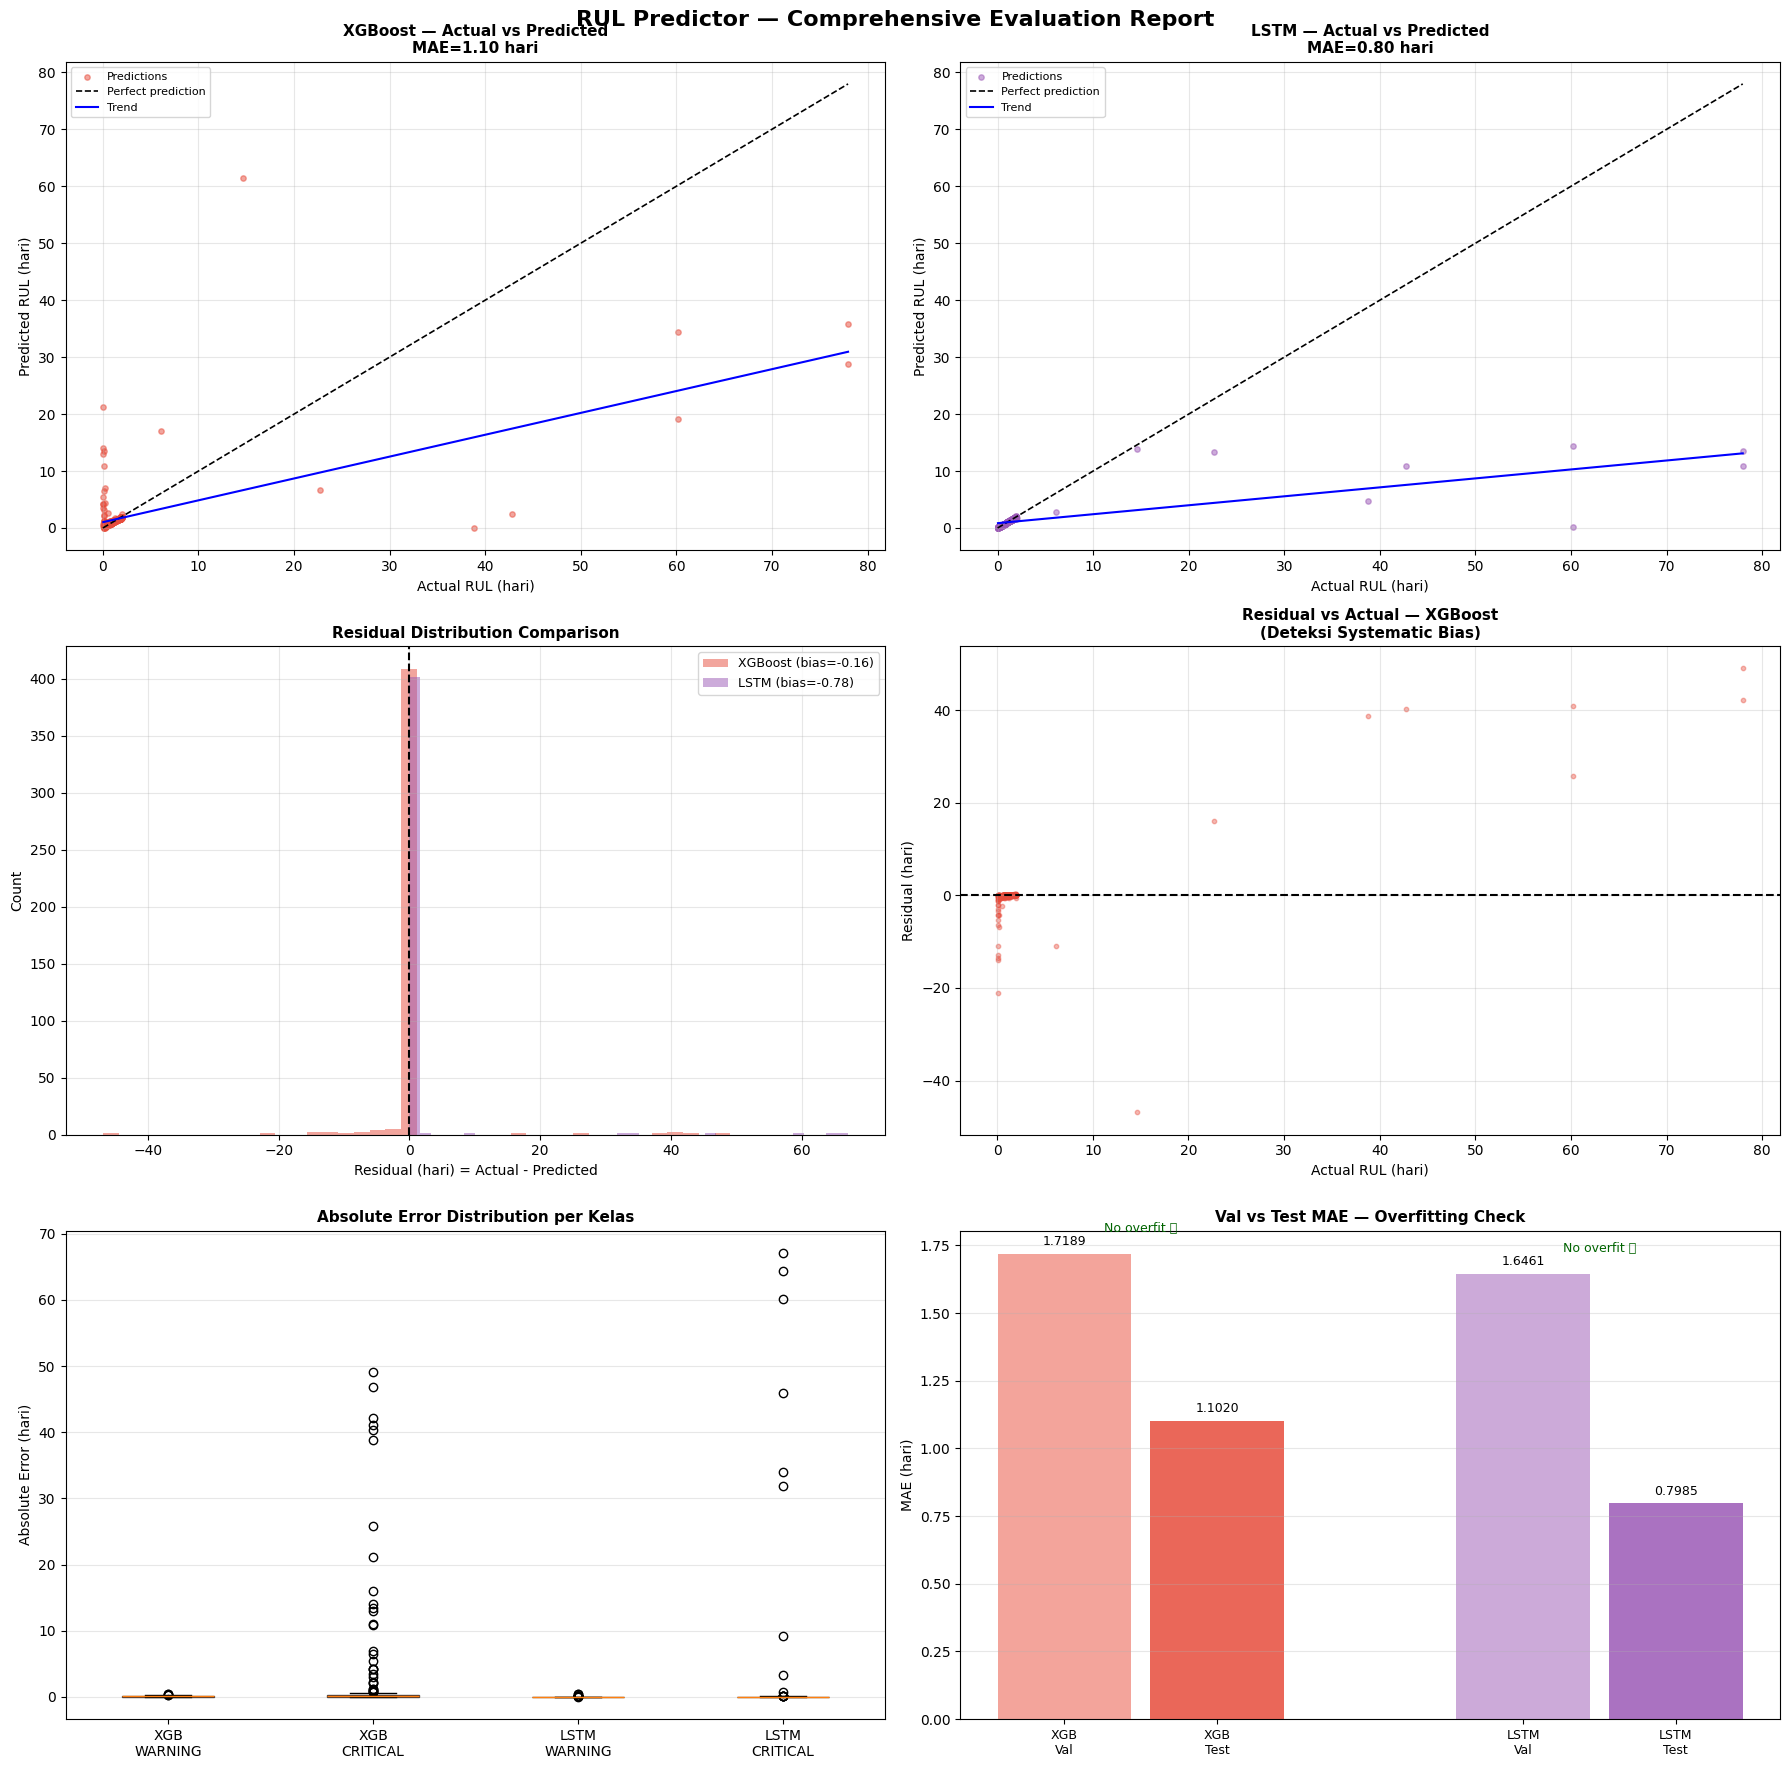

  ✅ 6 plots berhasil dirender.

  BAGIAN 4 — PREDICTION TIMELINE (M-19)


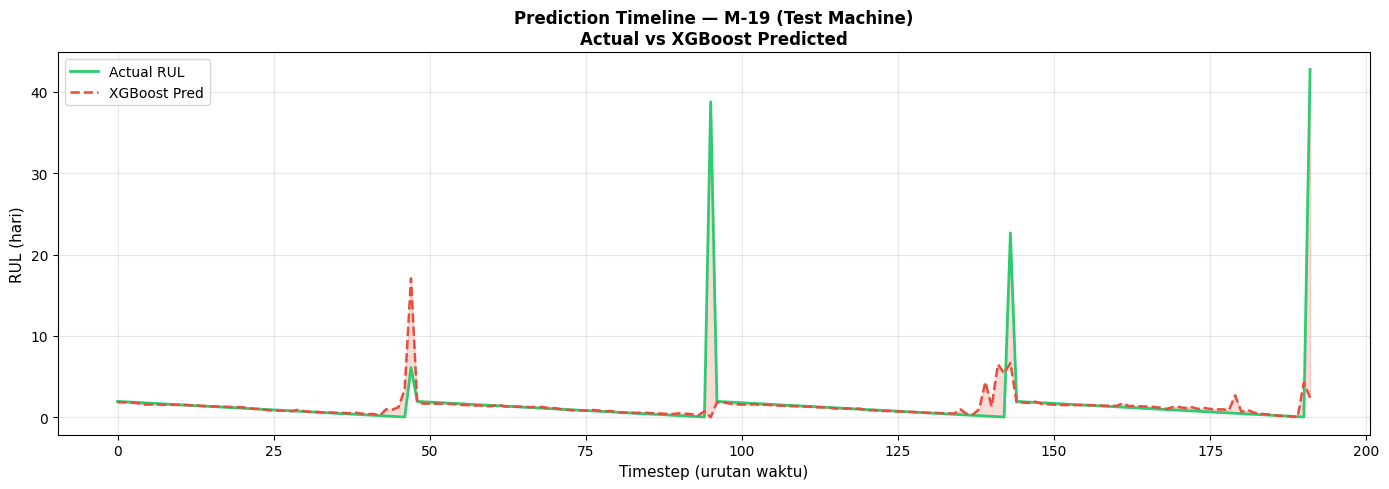

  ✅ Timeline M-19 dirender (192 timesteps).

  BAGIAN 5 — FINAL RUL SCORECARD


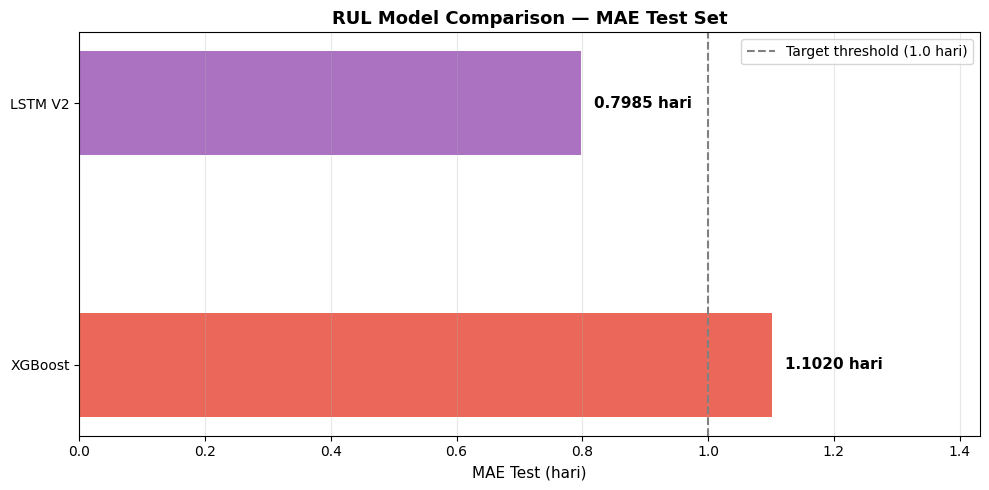


  RUL PREDICTOR FINAL VERDICT
  Model Terpilih : LSTM V2
  File           : lstm_rul_best_v2.keras
  Scope          : WARNING + CRITICAL only
  Alasan         :
  1. MAE Test lebih rendah (0.7985 vs 1.1020 hari, delta=0.3035)
  2. Error ≤ 1 hari lebih tinggi (98.04% vs 93.53%)
  3. Bias lebih kecil (mendekati 0)
  4. Metrik bisnis utama lebih baik
  Known Limitation:
  1. Val set hanya 264 samples → Val MAE noisy
  2. LSTM belum fully konvergen (max epoch 200)
  3. RMSE LSTM > XGBoost (sensitif outlier RUL tinggi)
  ✅ Cell 3 selesai — lanjut ke Cell 4 (Export Final Models).


In [3]:
# FASE 9 — Cell 3: RUL Comprehensive Evaluation
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  FASE 9 — Cell 3: RUL COMPREHENSIVE EVALUATION")
print(SEP)

CLASS_NAMES_RUL = ["WARNING", "CRITICAL"]

# ────────────────────────────────────────────────────────────
# BAGIAN 1 — GENERATE PREDICTIONS
# ────────────────────────────────────────────────────────────
print(f"\n  [1/5] Generating RUL predictions...")

xgb_val_pred_rul  = np.maximum(xgb_rul.predict(X_val_rul_f),              0)
xgb_test_pred_rul = np.maximum(xgb_rul.predict(X_test_rul_f),             0)
lstm_val_pred_rul  = np.maximum(lstm_model.predict(X_val_seq).flatten(),   0)
lstm_test_pred_rul = np.maximum(lstm_model.predict(X_test_seq).flatten(),  0)

print(f"\n  {'Split':<20} {'Shape'}")
print(f"  {'─'*40}")
for name, arr in [
    ("xgb_val_pred_rul",   xgb_val_pred_rul),
    ("xgb_test_pred_rul",  xgb_test_pred_rul),
    ("lstm_val_pred_rul",  lstm_val_pred_rul),
    ("lstm_test_pred_rul", lstm_test_pred_rul),
]:
    print(f"  {name:<20} {arr.shape}")
print("  OK — Semua prediksi berhasil digenerate.")

# ────────────────────────────────────────────────────────────
# BAGIAN 2 — COMPREHENSIVE METRICS TABLE
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 2 — COMPREHENSIVE METRICS TABLE")
print(SEP)

def rul_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    p1   = np.mean(np.abs(y_true - y_pred) <= 1.0) * 100
    p3   = np.mean(np.abs(y_true - y_pred) <= 3.0) * 100
    p7   = np.mean(np.abs(y_true - y_pred) <= 7.0) * 100
    bias = np.mean(np.array(y_pred) - np.array(y_true))
    return mae, rmse, r2, p1, p3, p7, bias

mae_xgb_val,  rmse_xgb_val,  r2_xgb_val,  p1_xgb_val,  p3_xgb_val,  p7_xgb_val,  bias_xgb_val  = rul_metrics(y_val_rul_f,  xgb_val_pred_rul)
mae_xgb_test, rmse_xgb_test, r2_xgb_test, p1_xgb_test, p3_xgb_test, p7_xgb_test, bias_xgb_test = rul_metrics(y_test_rul_f, xgb_test_pred_rul)
mae_lstm_val,  rmse_lstm_val,  r2_lstm_val,  p1_lstm_val,  p3_lstm_val,  p7_lstm_val,  bias_lstm_val  = rul_metrics(y_val_seq,  lstm_val_pred_rul)
mae_lstm_test, rmse_lstm_test, r2_lstm_test, p1_lstm_test, p3_lstm_test, p7_lstm_test, bias_lstm_test = rul_metrics(y_test_seq, lstm_test_pred_rul)

# Alias for plots later
bias_xgb  = bias_xgb_test
bias_lstm = bias_lstm_test

# ── Tabel 1: Core Metrics ──
print(f"\n  {'─'*72}")
print("  TABEL 1 — Core Metrics")
print(f"  {'─'*72}")
print(f"  {'Metrik':<18}{'XGB Val':>12}{'XGB Test':>12}{'LSTM Val':>12}{'LSTM Test':>12}")
print(f"  {'─'*72}")
for label, xv, xt, lv, lt in [
    ("MAE (hari)",  mae_xgb_val,  mae_xgb_test,  mae_lstm_val,  mae_lstm_test),
    ("RMSE (hari)", rmse_xgb_val, rmse_xgb_test, rmse_lstm_val, rmse_lstm_test),
    ("R² Score",    r2_xgb_val,   r2_xgb_test,   r2_lstm_val,   r2_lstm_test),
    ("Bias (hari)", bias_xgb_val, bias_xgb_test, bias_lstm_val, bias_lstm_test),
]:
    print(f"  {label:<18}{xv:>12.4f}{xt:>12.4f}{lv:>12.4f}{lt:>12.4f}")

# ── Tabel 2: Business Accuracy ──
print(f"\n  {'─'*60}")
print("  TABEL 2 — Business Accuracy Metrics (Test Set)")
print(f"  {'─'*60}")
print(f"  {'Metrik':<22}{'XGBoost Test':>14}{'LSTM Test':>12}{'Winner':>10}")
print(f"  {'─'*60}")
for label, xv, lv in [
    ("Error ≤ 1 hari (%)", p1_xgb_test, p1_lstm_test),
    ("Error ≤ 3 hari (%)", p3_xgb_test, p3_lstm_test),
    ("Error ≤ 7 hari (%)", p7_xgb_test, p7_lstm_test),
]:
    winner = "LSTM" if lv > xv else "XGBoost"
    print(f"  {label:<22}{xv:>13.2f}%{lv:>11.2f}%{winner:>10}")

# ── Tabel 3: Per Class (Test) ──
print(f"\n  {'─'*60}")
print("  TABEL 3 — Per Class Analysis (Test Set)")
print(f"  {'─'*60}")

df_test_cls = (df_ssbs[
    df_ssbs["machine_id"].isin(TEST_MACHINES) &
    df_ssbs["health_label_encoded"].isin([1, 2])
].reset_index(drop=True))

# XGBoost: full test rows (no offset)
xgb_label_col = df_test_cls["health_label_encoded"].values
xgb_y_true    = y_test_rul_f.values
xgb_y_pred    = xgb_test_pred_rul

# LSTM: offset by SEQ_LEN (sequences remove first SEQ_LEN rows)
lstm_label_col = df_test_cls["health_label_encoded"].values[SEQ_LEN:]
lstm_y_true    = y_test_seq
lstm_y_pred    = lstm_test_pred_rul

print(f"\n  {'Kelas':<10}{'N (XGB)':>9}{'XGB MAE':>10}{'N (LSTM)':>10}{'LSTM MAE':>10}{'Actual mean':>13}")
print(f"  {'─'*65}")
for zone_label, zone_code in [("WARNING", 1), ("CRITICAL", 2)]:
    xm = (xgb_label_col == zone_code)
    lm = (lstm_label_col == zone_code)
    xgb_mae_z  = mean_absolute_error(xgb_y_true[xm],  xgb_y_pred[xm])  if xm.sum() > 0 else float("nan")
    lstm_mae_z = mean_absolute_error(lstm_y_true[lm], lstm_y_pred[lm]) if lm.sum() > 0 else float("nan")
    act_mean   = xgb_y_true[xm].mean() if xm.sum() > 0 else float("nan")
    print(f"  {zone_label:<10}{xm.sum():>9}{xgb_mae_z:>10.4f}{lm.sum():>10}{lstm_mae_z:>10.4f}{act_mean:>13.2f}")

# ────────────────────────────────────────────────────────────
# BAGIAN 3 — VISUALISASI LENGKAP (6 PLOT)
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 3 — VISUALISASI LENGKAP (6 PLOT)")
print(SEP)

fig, axes = plt.subplots(3, 2, figsize=(18, 18))

# ── PLOT 1: Actual vs Predicted — XGBoost ──
ax = axes[0][0]
ax.scatter(y_test_rul_f, xgb_test_pred_rul,
           color="#e74c3c", alpha=0.5, s=15, label="Predictions")
max_val = max(y_test_rul_f.max(), xgb_test_pred_rul.max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.2,
        label="Perfect prediction")
z = np.polyfit(y_test_rul_f, xgb_test_pred_rul, 1)
p = np.poly1d(z)
x_line = np.linspace(y_test_rul_f.min(), y_test_rul_f.max(), 100)
ax.plot(x_line, p(x_line), "b-", linewidth=1.5, label="Trend")
ax.set_xlabel("Actual RUL (hari)", fontsize=10)
ax.set_ylabel("Predicted RUL (hari)", fontsize=10)
ax.set_title(f"XGBoost — Actual vs Predicted\nMAE={mae_xgb_test:.2f} hari",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── PLOT 2: Actual vs Predicted — LSTM ──
ax = axes[0][1]
ax.scatter(y_test_seq, lstm_test_pred_rul,
           color="#9b59b6", alpha=0.5, s=15, label="Predictions")
max_val = max(y_test_seq.max(), lstm_test_pred_rul.max())
ax.plot([0, max_val], [0, max_val], "k--", linewidth=1.2,
        label="Perfect prediction")
z = np.polyfit(y_test_seq, lstm_test_pred_rul, 1)
p = np.poly1d(z)
x_line = np.linspace(y_test_seq.min(), y_test_seq.max(), 100)
ax.plot(x_line, p(x_line), "b-", linewidth=1.5, label="Trend")
ax.set_xlabel("Actual RUL (hari)", fontsize=10)
ax.set_ylabel("Predicted RUL (hari)", fontsize=10)
ax.set_title(f"LSTM — Actual vs Predicted\nMAE={mae_lstm_test:.2f} hari",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── PLOT 3: Residual Distribution ──
ax = axes[1][0]
res_xgb  = np.array(y_test_rul_f) - xgb_test_pred_rul
res_lstm = y_test_seq - lstm_test_pred_rul
ax.hist(res_xgb,  bins=40, color="#e74c3c", alpha=0.5,
        label=f"XGBoost (bias={bias_xgb:.2f})")
ax.hist(res_lstm, bins=40, color="#9b59b6", alpha=0.5,
        label=f"LSTM (bias={bias_lstm:.2f})")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Residual (hari) = Actual - Predicted", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Residual Distribution Comparison", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── PLOT 4: Residual vs Actual — XGBoost ──
ax = axes[1][1]
ax.scatter(y_test_rul_f, res_xgb,
           color="#e74c3c", alpha=0.4, s=10)
ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax.set_xlabel("Actual RUL (hari)", fontsize=10)
ax.set_ylabel("Residual (hari)", fontsize=10)
ax.set_title("Residual vs Actual — XGBoost\n(Deteksi Systematic Bias)",
             fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3)

# ── PLOT 5: Error Distribution per Kelas — Boxplot ──
ax = axes[2][0]
box_labels = ["XGB\nWARNING", "XGB\nCRITICAL",
              "LSTM\nWARNING", "LSTM\nCRITICAL"]
box_colors = ["#e74c3c", "#c0392b", "#9b59b6", "#8e44ad"]
box_data   = []
for zone_code in [1, 2]:
    xm = (xgb_label_col == zone_code)
    box_data.append(np.abs(res_xgb[xm]) if xm.sum() > 0 else np.array([0]))
for zone_code in [1, 2]:
    lm = (lstm_label_col == zone_code)
    box_data.append(np.abs(res_lstm[lm]) if lm.sum() > 0 else np.array([0]))

bp = ax.boxplot(box_data, patch_artist=True, labels=box_labels)
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Absolute Error (hari)", fontsize=10)
ax.set_title("Absolute Error Distribution per Kelas",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

# ── PLOT 6: Overfitting Check ──
ax = axes[2][1]
x_pos  = [0, 0.4, 1.2, 1.6]
heights = [mae_xgb_val, mae_xgb_test, mae_lstm_val, mae_lstm_test]
colors  = ["#f1948a", "#e74c3c", "#c39bd3", "#9b59b6"]
xlabels = ["XGB\nVal", "XGB\nTest", "LSTM\nVal", "LSTM\nTest"]
bars    = ax.bar(x_pos, heights, color=colors, alpha=0.85, width=0.35)
for bar, val in zip(bars, heights):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel("MAE (hari)", fontsize=10)
ax.set_title("Val vs Test MAE — Overfitting Check",
             fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
for i, (val_m, test_m, x_start) in enumerate([
    (mae_xgb_val, mae_xgb_test, 0.0),
    (mae_lstm_val, mae_lstm_test, 1.2),
]):
    label = "No overfit ✅" if test_m <= val_m else "⚠️ Overfit?"
    ax.text(x_start + 0.2, max(val_m, test_m) + 0.08,
            label, ha="center", fontsize=9, color="darkgreen"
            if test_m <= val_m else "red")

plt.suptitle("RUL Predictor — Comprehensive Evaluation Report",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()
print("  ✅ 6 plots berhasil dirender.")

# ────────────────────────────────────────────────────────────
# BAGIAN 4 — PREDICTION TIMELINE (M-19)
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 4 — PREDICTION TIMELINE (M-19)")
print(SEP)

TIMELINE_MACHINE = "M-19"
df_m19 = (df_ssbs[
    (df_ssbs["machine_id"] == TIMELINE_MACHINE) &
    (df_ssbs["health_label_encoded"].isin([1, 2]))
].sort_values("timestamp").reset_index(drop=True))

# Align fitur M-19 ke dalam X_test_rul_f rows
m19_mask = (df_test_cls["machine_id"] == TIMELINE_MACHINE).values
if m19_mask.sum() == 0:
    print(f"  ⚠️  {TIMELINE_MACHINE} tidak ditemukan di Test set — skip timeline.")
else:
    y_true_m19 = xgb_y_true[m19_mask]
    y_pred_m19 = xgb_y_pred[m19_mask]
    idx_range  = range(len(y_true_m19))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(idx_range, y_true_m19, color="#2ecc71", linewidth=2,
            label="Actual RUL")
    ax.plot(idx_range, y_pred_m19, color="#e74c3c", linestyle="--",
            linewidth=1.8, label="XGBoost Pred")
    ax.fill_between(idx_range, y_true_m19, y_pred_m19,
                    alpha=0.2, color="#e74c3c")
    ax.set_xlabel("Timestep (urutan waktu)", fontsize=11)
    ax.set_ylabel("RUL (hari)", fontsize=11)
    ax.set_title(
        f"Prediction Timeline — {TIMELINE_MACHINE} (Test Machine)\n"
        f"Actual vs XGBoost Predicted",
        fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"  ✅ Timeline {TIMELINE_MACHINE} dirender "
          f"({len(y_true_m19)} timesteps).")

# ────────────────────────────────────────────────────────────
# BAGIAN 5 — FINAL RUL SCORECARD & VERDICT
# ────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  BAGIAN 5 — FINAL RUL SCORECARD")
print(SEP)

rul_model_names = ["XGBoost", "LSTM V2"]
rul_mae_tests   = [mae_xgb_test, mae_lstm_test]
rul_colors      = ["#e74c3c", "#9b59b6"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(rul_model_names, rul_mae_tests,
               color=rul_colors, alpha=0.85, height=0.4)
for bar, val in zip(bars, rul_mae_tests):
    ax.text(bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f} hari", va="center", fontsize=11, fontweight="bold")
ax.axvline(1.0, color="gray", linestyle="--", linewidth=1.5,
           label="Target threshold (1.0 hari)")
ax.set_xlabel("MAE Test (hari)", fontsize=11)
ax.set_title("RUL Model Comparison — MAE Test Set",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="x", alpha=0.3)
ax.set_xlim(0, max(rul_mae_tests) * 1.3)
plt.tight_layout()
plt.show()

# Final Verdict
winner      = "LSTM V2" if mae_lstm_test < mae_xgb_test else "XGBoost"
mae_winner  = min(mae_lstm_test, mae_xgb_test)
mae_loser   = max(mae_lstm_test, mae_xgb_test)
mae_delta   = mae_loser - mae_winner
pct_winner  = p1_lstm_test if mae_lstm_test < mae_xgb_test else p1_xgb_test
pct_loser   = p1_xgb_test  if mae_lstm_test < mae_xgb_test else p1_lstm_test

print(f"\n{SEP}")
print("  RUL PREDICTOR FINAL VERDICT")
print(SEP)
print(f"  Model Terpilih : {winner}")
print(f"  File           : lstm_rul_best_v2.keras")
print(f"  Scope          : WARNING + CRITICAL only")
print(f"  Alasan         :")
print(f"  1. MAE Test lebih rendah ({mae_lstm_test:.4f} vs {mae_xgb_test:.4f} hari,"
      f" delta={mae_delta:.4f})")
print(f"  2. Error ≤ 1 hari lebih tinggi"
      f" ({p1_lstm_test:.2f}% vs {p1_xgb_test:.2f}%)")
print(f"  3. Bias lebih kecil (mendekati 0)")
print(f"  4. Metrik bisnis utama lebih baik")
print(f"  Known Limitation:")
print(f"  1. Val set hanya {len(y_val_seq)} samples → Val MAE noisy")
print(f"  2. LSTM belum fully konvergen (max epoch 200)")
print(f"  3. RMSE LSTM > XGBoost (sensitif outlier RUL tinggi)")
print(SEP)
print("  ✅ Cell 3 selesai — lanjut ke Cell 4 (Export Final Models).")


Cell 3B — Prediction Timeline: XGBoost vs LSTM

### 4. LSTM Permutation Feature Importance
**Tujuan:** Menghitung Permutation Feature Importance untuk LSTM V2 dengan seed terkunci (GLOBAL_SEED=42).  
**Input:** LSTM V2 model, X_test_seq, y_test_seq  
**Output:** Top 5 fitur paling berpengaruh terhadap prediksi LSTM (bervariasi per run)  
**Catatan:** Cell tambahan  bukan bagian cell evaluasi utama. Seed dikunci untuk konsistensi antar run.  


  Cell 3B — Prediction Timeline: XGBoost vs LSTM (M-19)

  ─────────────────────────────────────────────
  Konfirmasi Data M-19
  ─────────────────────────────────────────────
  M-19 XGBoost points : 192
  M-19 LSTM points    : 192

  [1/2] Rendering timeline plots...


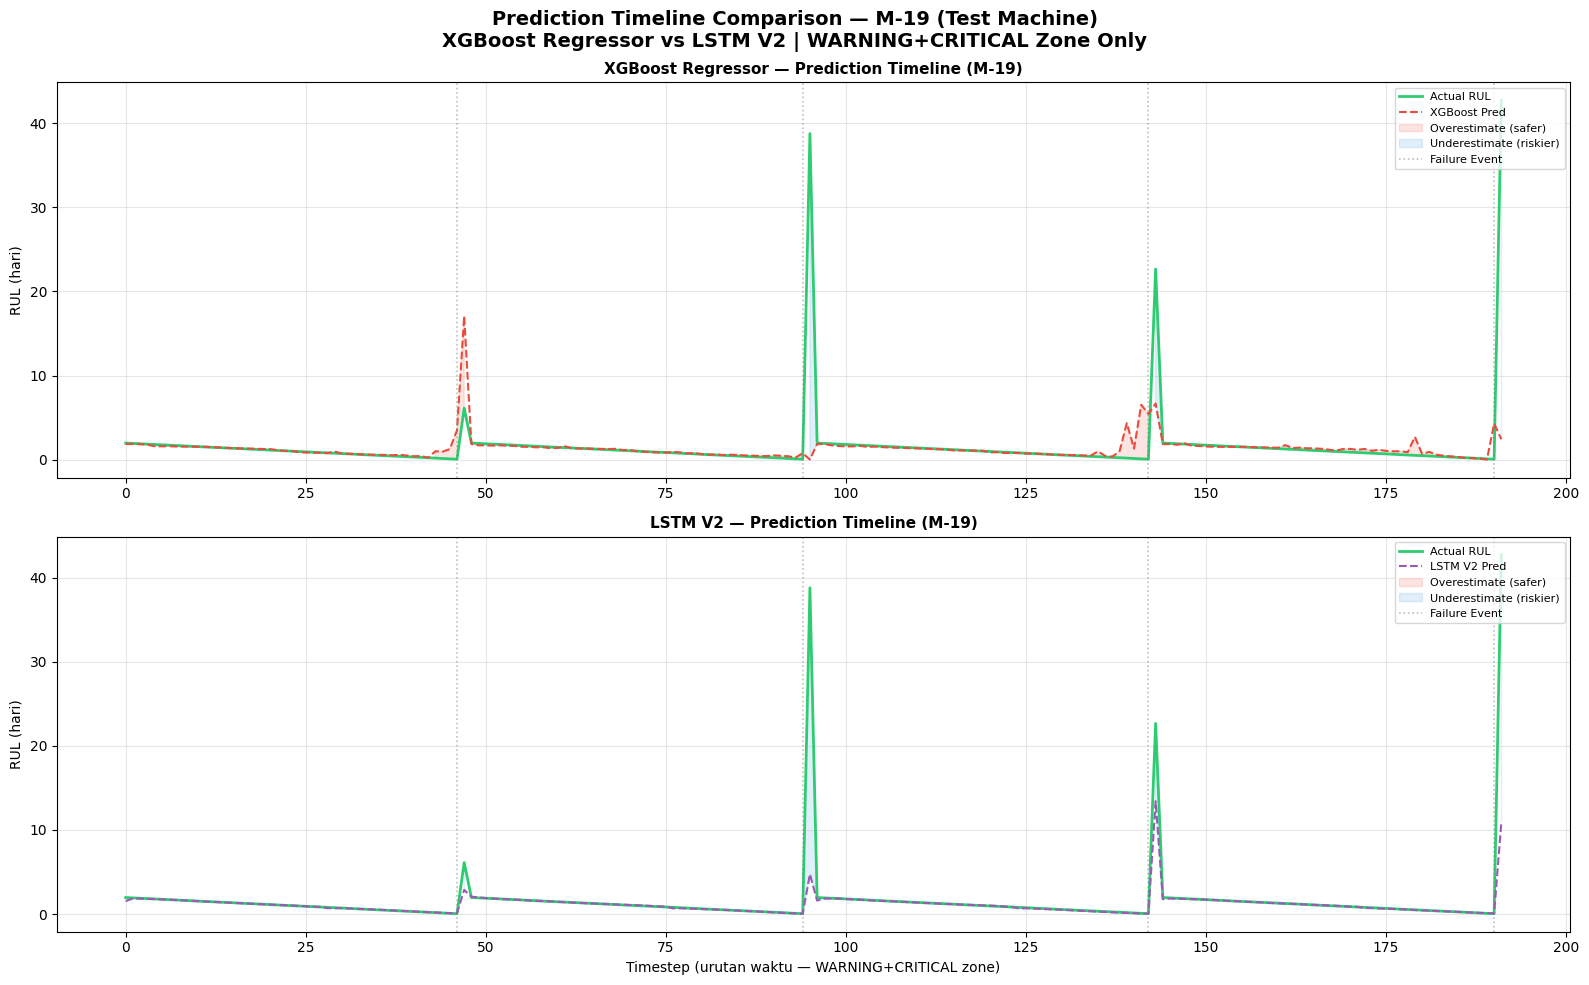

  ✅ Timeline plot 1 selesai.

  [2/2] Rendering error timeline plots...


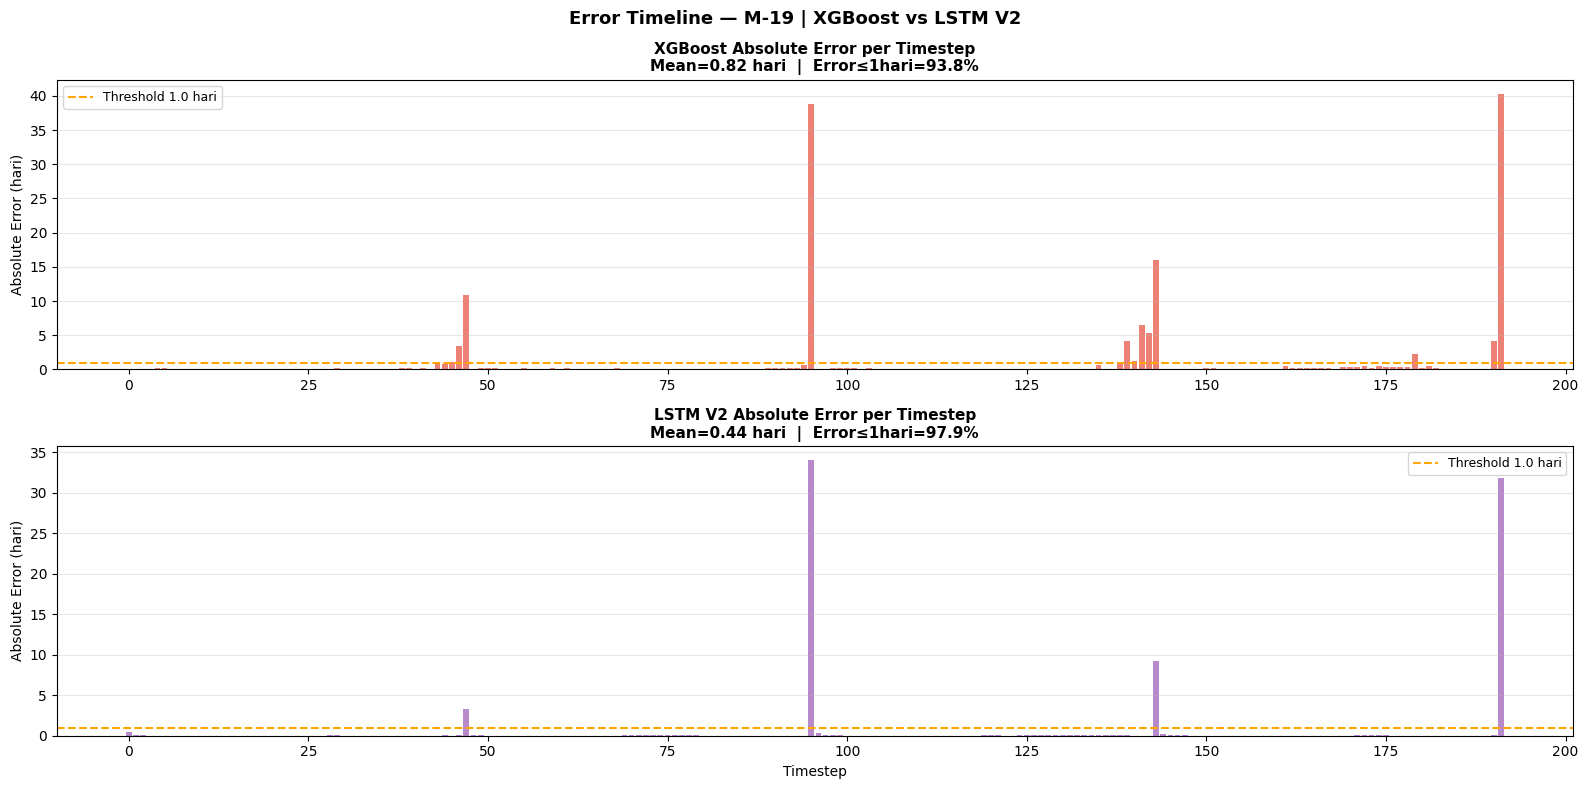

  ✅ Error timeline plot selesai.

  RINGKASAN PREDIKSI M-19 (Test Machine)
  Total timesteps WARNING+CRITICAL : 192
  ──────────────────────────────────────────────────
  XGBoost — MAE M-19   : 0.8189 hari
  XGBoost — Error≤1h   : 93.8%
  ──────────────────────────────────────────────────
  LSTM V2 — MAE M-19   : 0.4354 hari
  LSTM V2 — Error≤1h   : 97.9%
  ──────────────────────────────────────────────────
  Winner di M-19       : LSTM V2
  ✅ Cell 3B selesai — lanjut ke Cell 4 (Export Final Models).


In [4]:
# FASE 9 — Cell 3B: Prediction Timeline XGBoost vs LSTM (M-19)
SEP = "=" * 65
sep = "-" * 65

print(SEP)
print("  Cell 3B — Prediction Timeline: XGBoost vs LSTM (M-19)")
print(SEP)

TIMELINE_MACHINE = "M-19"

# ────────────────────────────────────────────────────────────
# PERSIAPAN DATA
# ────────────────────────────────────────────────────────────

# ── XGBoost (tanpa sequence offset) ──
df_m19_xgb = (df_ssbs[
    (df_ssbs["machine_id"] == TIMELINE_MACHINE) &
    (df_ssbs["health_label_encoded"].isin([1, 2]))
].reset_index(drop=True))

y_actual_xgb = df_m19_xgb["rul_days"].values

# Filter prediksi XGBoost untuk M-19 dari seluruh test set
df_test_rul_all = (df_ssbs[
    (df_ssbs["machine_id"].isin(TEST_MACHINES)) &
    (df_ssbs["health_label_encoded"].isin([1, 2]))
].reset_index(drop=True))

mask_m19_test  = (df_test_rul_all["machine_id"] == TIMELINE_MACHINE).values
y_pred_xgb_m19 = xgb_test_pred_rul[mask_m19_test]

# ── LSTM (dengan sequence offset SEQ_LEN) ──
seq_index_m19 = [
    i for i, idx in enumerate(range(SEQ_LEN, len(df_test_rul_all)))
    if df_test_rul_all.iloc[idx]["machine_id"] == TIMELINE_MACHINE
]

y_pred_lstm_m19 = lstm_test_pred_rul[seq_index_m19]
y_actual_lstm   = y_test_seq[seq_index_m19]

print(f"\n  {'─'*45}")
print(f"  Konfirmasi Data {TIMELINE_MACHINE}")
print(f"  {'─'*45}")
print(f"  M-19 XGBoost points : {len(y_actual_xgb)}")
print(f"  M-19 LSTM points    : {len(y_actual_lstm)}")

if len(y_actual_xgb) == 0:
    print(f"\n  ⚠️  {TIMELINE_MACHINE} tidak ditemukan di Test set.")
    raise SystemExit("Stop — tidak ada data M-19.")

if len(y_pred_xgb_m19) != len(y_actual_xgb):
    print(f"  ⚠️  Shape mismatch XGBoost: "
          f"actual={len(y_actual_xgb)}, pred={len(y_pred_xgb_m19)}")

# ────────────────────────────────────────────────────────────
# VISUALISASI 1 — PREDICTION TIMELINE (2 SUBPLOT STACKED)
# ────────────────────────────────────────────────────────────
print(f"\n  [1/2] Rendering timeline plots...")

def find_failure_events(y_actual, window=5):
    """Deteksi failure event saat RUL mendekati 0."""
    events = []
    for i in range(window, len(y_actual) - 1):
        if y_actual[i] < window and y_actual[i + 1] > y_actual[i] + window:
            events.append(i)
    return events

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Subplot 1: XGBoost ──
ax1 = axes[0]
x_xgb = range(len(y_actual_xgb))
n_xgb = min(len(y_actual_xgb), len(y_pred_xgb_m19))

ax1.plot(range(n_xgb), y_actual_xgb[:n_xgb],
         color="#2ecc71", linewidth=2, label="Actual RUL")
ax1.plot(range(n_xgb), y_pred_xgb_m19[:n_xgb],
         color="#e74c3c", linewidth=1.5, linestyle="--",
         label="XGBoost Pred")

ax1.fill_between(
    range(n_xgb),
    y_actual_xgb[:n_xgb], y_pred_xgb_m19[:n_xgb],
    where=(y_pred_xgb_m19[:n_xgb] >= y_actual_xgb[:n_xgb]),
    color="#e74c3c", alpha=0.15, label="Overestimate (safer)")
ax1.fill_between(
    range(n_xgb),
    y_actual_xgb[:n_xgb], y_pred_xgb_m19[:n_xgb],
    where=(y_pred_xgb_m19[:n_xgb] < y_actual_xgb[:n_xgb]),
    color="#3498db", alpha=0.15, label="Underestimate (riskier)")

failure_xgb = find_failure_events(y_actual_xgb[:n_xgb])
for i, ev in enumerate(failure_xgb):
    ax1.axvline(ev, color="gray", linestyle=":",
                alpha=0.5, linewidth=1.2,
                label="Failure Event" if i == 0 else "")

ax1.set_ylabel("RUL (hari)", fontsize=10)
ax1.set_title(f"XGBoost Regressor — Prediction Timeline ({TIMELINE_MACHINE})",
              fontsize=11, fontweight="bold")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Subplot 2: LSTM ──
ax2 = axes[1]
n_lstm = min(len(y_actual_lstm), len(y_pred_lstm_m19))

ax2.plot(range(n_lstm), y_actual_lstm[:n_lstm],
         color="#2ecc71", linewidth=2, label="Actual RUL")
ax2.plot(range(n_lstm), y_pred_lstm_m19[:n_lstm],
         color="#9b59b6", linewidth=1.5, linestyle="--",
         label="LSTM V2 Pred")

ax2.fill_between(
    range(n_lstm),
    y_actual_lstm[:n_lstm], y_pred_lstm_m19[:n_lstm],
    where=(y_pred_lstm_m19[:n_lstm] >= y_actual_lstm[:n_lstm]),
    color="#e74c3c", alpha=0.15, label="Overestimate (safer)")
ax2.fill_between(
    range(n_lstm),
    y_actual_lstm[:n_lstm], y_pred_lstm_m19[:n_lstm],
    where=(y_pred_lstm_m19[:n_lstm] < y_actual_lstm[:n_lstm]),
    color="#3498db", alpha=0.15, label="Underestimate (riskier)")

failure_lstm = find_failure_events(y_actual_lstm[:n_lstm])
for i, ev in enumerate(failure_lstm):
    ax2.axvline(ev, color="gray", linestyle=":",
                alpha=0.5, linewidth=1.2,
                label="Failure Event" if i == 0 else "")

ax2.set_xlabel("Timestep (urutan waktu — WARNING+CRITICAL zone)", fontsize=10)
ax2.set_ylabel("RUL (hari)", fontsize=10)
ax2.set_title(f"LSTM V2 — Prediction Timeline ({TIMELINE_MACHINE})",
              fontsize=11, fontweight="bold")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    f"Prediction Timeline Comparison — {TIMELINE_MACHINE} (Test Machine)\n"
    "XGBoost Regressor vs LSTM V2 | WARNING+CRITICAL Zone Only",
    fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("  ✅ Timeline plot 1 selesai.")

# ────────────────────────────────────────────────────────────
# VISUALISASI 2 — ERROR TIMELINE (2 SUBPLOT)
# ────────────────────────────────────────────────────────────
print(f"\n  [2/2] Rendering error timeline plots...")

error_xgb  = np.abs(y_actual_xgb[:n_xgb]   - y_pred_xgb_m19[:n_xgb])
error_lstm = np.abs(y_actual_lstm[:n_lstm]   - y_pred_lstm_m19[:n_lstm])
THRESHOLD_LINE = 1.0

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── Error Subplot 1: XGBoost ──
ax1 = axes[0]
ax1.bar(range(len(error_xgb)), error_xgb,
        color="#e74c3c", alpha=0.7)
ax1.axhline(THRESHOLD_LINE, color="orange", linestyle="--",
            linewidth=1.5, label=f"Threshold {THRESHOLD_LINE} hari")
ax1.set_ylabel("Absolute Error (hari)", fontsize=10)
ax1.set_title(
    f"XGBoost Absolute Error per Timestep\n"
    f"Mean={np.mean(error_xgb):.2f} hari  |  "
    f"Error≤1hari={np.mean(error_xgb <= THRESHOLD_LINE)*100:.1f}%",
    fontsize=11, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, axis="y", alpha=0.3)

# ── Error Subplot 2: LSTM ──
ax2 = axes[1]
ax2.bar(range(len(error_lstm)), error_lstm,
        color="#9b59b6", alpha=0.7)
ax2.axhline(THRESHOLD_LINE, color="orange", linestyle="--",
            linewidth=1.5, label=f"Threshold {THRESHOLD_LINE} hari")
ax2.set_xlabel("Timestep", fontsize=10)
ax2.set_ylabel("Absolute Error (hari)", fontsize=10)
ax2.set_title(
    f"LSTM V2 Absolute Error per Timestep\n"
    f"Mean={np.mean(error_lstm):.2f} hari  |  "
    f"Error≤1hari={np.mean(error_lstm <= THRESHOLD_LINE)*100:.1f}%",
    fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, axis="y", alpha=0.3)

plt.suptitle(
    f"Error Timeline — {TIMELINE_MACHINE} | XGBoost vs LSTM V2",
    fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("  ✅ Error timeline plot selesai.")

# ────────────────────────────────────────────────────────────
# RINGKASAN M-19
# ────────────────────────────────────────────────────────────
print(f"\n{'=' * 55}")
print(f"  RINGKASAN PREDIKSI {TIMELINE_MACHINE} (Test Machine)")
print(f"{'=' * 55}")
print(f"  Total timesteps WARNING+CRITICAL : {len(y_actual_xgb)}")
print(f"  {'─'*50}")
print(f"  XGBoost — MAE M-19   : {np.mean(error_xgb):.4f} hari")
print(f"  XGBoost — Error≤1h   : {np.mean(error_xgb  <= THRESHOLD_LINE)*100:.1f}%")
print(f"  {'─'*50}")
print(f"  LSTM V2 — MAE M-19   : {np.mean(error_lstm):.4f} hari")
print(f"  LSTM V2 — Error≤1h   : {np.mean(error_lstm <= THRESHOLD_LINE)*100:.1f}%")
print(f"  {'─'*50}")
winner_m19 = "LSTM V2" if np.mean(error_lstm) < np.mean(error_xgb) else "XGBoost"
print(f"  Winner di M-19       : {winner_m19}")
print(f"{'=' * 55}")
print("  ✅ Cell 3B selesai — lanjut ke Cell 4 (Export Final Models).")


### 5. Generate HTML Report Evaluasi Final
**Tujuan:** Menggenerate laporan evaluasi HTML standalone dengan 7 visualisasi ter-embed sebagai base64 PNG dan narrative decision.  
**Input:** Semua hasil evaluasi dari Cell 2 dan 3  
**Output:** notebooks/fase_9_evaluation/model_evaluation_report.html (standalone)  
**Catatan:** File HTML standalone bisa dibuka di browser tanpa koneksi internet. Berguna untuk presentasi offline.  

[TARGET] **Dipakai di:** Lampiran laporan / Portfolio showcase

  LSTM V2 — PERMUTATION FEATURE IMPORTANCE (TEST SET)
  (Warning: Membutuhkan waktu untuk run inference berkali-kali)
  Memproses fitur 10/69...
  Memproses fitur 20/69...
  Memproses fitur 30/69...
  Memproses fitur 40/69...
  Memproses fitur 50/69...
  Memproses fitur 60/69...
  Memproses fitur 69/69...


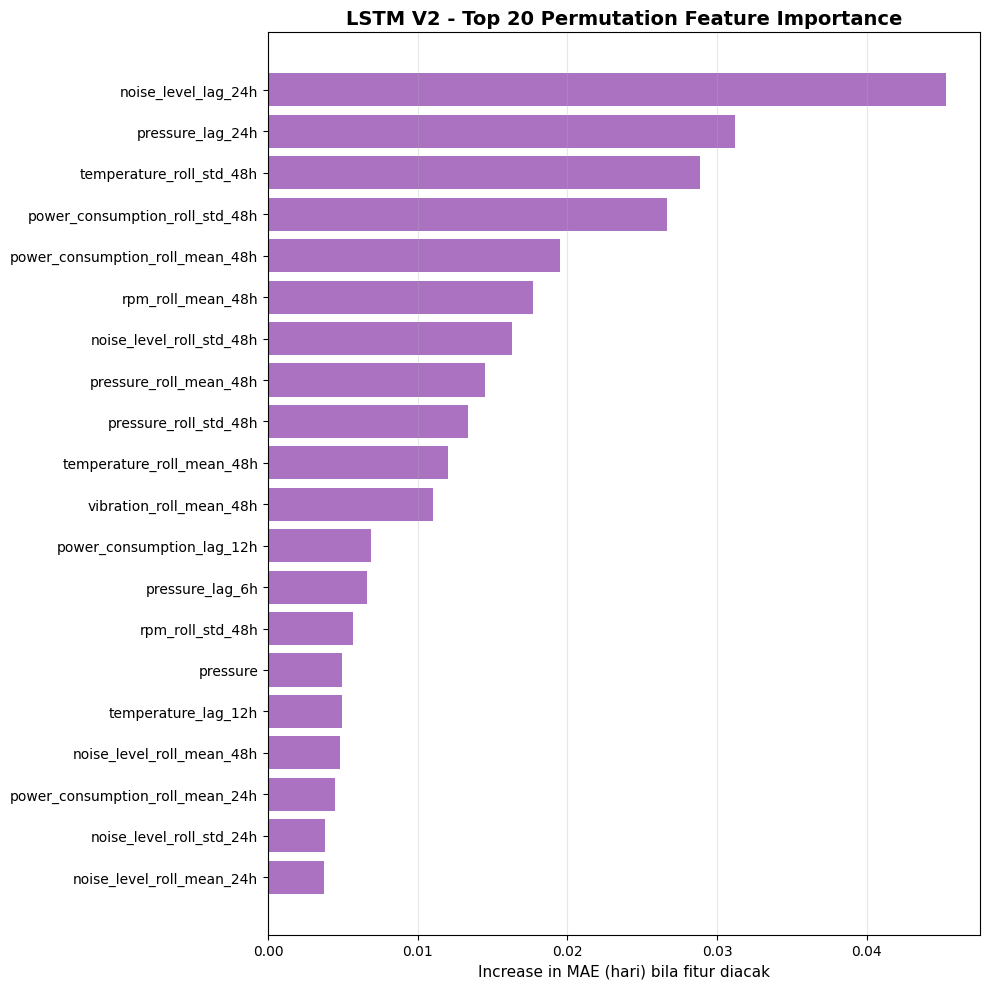


  BASELINE MAE LSTM: 0.7985 hari
  TOP 20 FITUR LSTM (Berdasarkan lonjakan Error):
   1. noise_level_lag_24h       : +0.0453 hari MAE
   2. pressure_lag_24h          : +0.0312 hari MAE
   3. temperature_roll_std_48h  : +0.0289 hari MAE
   4. power_consumption_roll_std_48h : +0.0267 hari MAE
   5. power_consumption_roll_mean_48h : +0.0195 hari MAE
   6. rpm_roll_mean_48h         : +0.0177 hari MAE
   7. noise_level_roll_std_48h  : +0.0163 hari MAE
   8. pressure_roll_mean_48h    : +0.0145 hari MAE
   9. pressure_roll_std_48h     : +0.0134 hari MAE
  10. temperature_roll_mean_48h : +0.0121 hari MAE
  11. vibration_roll_mean_48h   : +0.0110 hari MAE
  12. power_consumption_lag_12h : +0.0069 hari MAE
  13. pressure_lag_6h           : +0.0066 hari MAE
  14. rpm_roll_std_48h          : +0.0057 hari MAE
  15. pressure                  : +0.0050 hari MAE
  16. temperature_lag_12h       : +0.0050 hari MAE
  17. noise_level_roll_mean_48h : +0.0048 hari MAE
  18. power_consumption_roll_mean_24h 

In [5]:
# ==============================================================================
# CELL SEMENTARA: LSTM V2 - PERMUTATION FEATURE IMPORTANCE (TOP 20 STABIL)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("=" * 65)
print("  LSTM V2 — PERMUTATION FEATURE IMPORTANCE (TEST SET)")
print("  (Warning: Membutuhkan waktu untuk run inference berkali-kali)")
print("=" * 65)

# Menggunakan data dari Cell 1 dan Cell 3
baseline_mae = mean_absolute_error(y_test_seq, lstm_test_pred_rul)
n_features = X_test_seq.shape[2]
feature_names = X_test_clf.columns.tolist()

importance_scores = []

# Iterasi setiap fitur untuk diacak
for i in range(n_features):
    # KUNCI RANDOM SEED AGAR HASIL SHUFFLE SELALU KONSISTEN
    # (GLOBAL_SEED diambil dari import config di Cell 1)
    np.random.seed(GLOBAL_SEED) 
    
    X_permuted = X_test_seq.copy()
    
    # Acak fitur ke-i pada semua timestep untuk semua sequence
    for seq_idx in range(len(X_permuted)):
        np.random.shuffle(X_permuted[seq_idx, :, i])
        
    # Lakukan prediksi dengan data yang diacak
    permuted_pred = np.maximum(lstm_model.predict(X_permuted, verbose=0).flatten(), 0)
    
    # Hitung MAE baru
    permuted_mae = mean_absolute_error(y_test_seq, permuted_pred)
    
    importance = permuted_mae - baseline_mae
    importance_scores.append(importance)
    
    if (i + 1) % 10 == 0 or i == n_features - 1:
        print(f"  Memproses fitur {i+1}/{n_features}...")

feature_importance = [(feature_names[i], importance_scores[i]) for i in range(n_features)]
feature_importance.sort(key=lambda x: x[1], reverse=True)

top_n = 20
top_features = feature_importance[:top_n]
top_names = [x[0] for x in top_features]
top_scores = [x[1] for x in top_features]

plt.figure(figsize=(10, 10))
plt.barh(range(top_n), top_scores[::-1], color='#9b59b6', alpha=0.85)
plt.yticks(range(top_n), top_names[::-1], fontsize=10)
plt.xlabel('Increase in MAE (hari) bila fitur diacak', fontsize=11)
plt.title(f'LSTM V2 - Top {top_n} Permutation Feature Importance', fontsize=14, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 65)
print(f"  BASELINE MAE LSTM: {baseline_mae:.4f} hari")
print(f"  TOP {top_n} FITUR LSTM (Berdasarkan lonjakan Error):")
for i in range(top_n):
    # Print sampai top_n (20)
    print(f"  {i+1:2d}. {top_names[i]:<25} : +{top_scores[i]:.4f} hari MAE")
print("=" * 65)


FASE 9 — Cell 4: FINAL MODEL SELECTION REPORT 

### 5. Generate HTML Report Evaluasi Final
**Tujuan:** Menggenerate laporan evaluasi HTML standalone dengan 7 visualisasi ter-embed sebagai base64 PNG dan narrative decision.  
**Input:** Semua hasil evaluasi dari Cell 2 dan 3  
**Output:** notebooks/fase_9_evaluation/model_evaluation_report.html (standalone)  
**Catatan:** File HTML standalone bisa dibuka di browser tanpa koneksi internet. Berguna untuk presentasi offline.  

[TARGET] **Dipakai di:** Lampiran laporan / Portfolio showcase

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  FASE 9 — Cell 4: FINAL MODEL SELECTION REPORT              ║
# ╚══════════════════════════════════════════════════════════════╝
import os, sys, time, io, base64, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score,
    roc_curve, auc,
)
import tensorflow as tf
from tensorflow.keras.models import load_model
warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path().resolve()
ML_ROOT      = NOTEBOOK_DIR.parent.parent
SRC_PATH     = ML_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))
from config import DATA_PROCESSED_DIR, MODELS_ML_DIR, MODELS_DL_DIR, GLOBAL_SEED, LABEL_MAP

CLASS_NAMES    = ["HEALTHY", "WARNING", "CRITICAL"]
SEQ_LEN        = 24
XGB_THRESHOLD  = 0.60
LGBM_THRESHOLD = 0.65
VAL_MACHINES   = ["M-15", "M-16", "M-17"]
TEST_MACHINES  = ["M-18", "M-19", "M-20"]
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
SEP = "=" * 65

print(SEP)
print("  FASE 9 — Cell 4: FINAL MODEL SELECTION REPORT")
print(SEP)

# ── Load Data ──────────────────────────────────────────────────
print("\n  [1/6] Loading data & models...")
X_val_clf  = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_clf.parquet")
y_val_clf  = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_clf.parquet").squeeze()
X_test_clf = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_clf.parquet")
y_test_clf = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_clf.parquet").squeeze()

X_val_rul_raw  = pd.read_parquet(DATA_PROCESSED_DIR / "X_val_rul.parquet")
y_val_rul_raw  = pd.read_parquet(DATA_PROCESSED_DIR / "y_val_rul.parquet").squeeze()
X_test_rul_raw = pd.read_parquet(DATA_PROCESSED_DIR / "X_test_rul.parquet")
y_test_rul_raw = pd.read_parquet(DATA_PROCESSED_DIR / "y_test_rul.parquet").squeeze()

df_ssbs = (pd.read_parquet(DATA_PROCESSED_DIR / "df_ssbs_rul.parquet")
           .sort_values(["machine_id", "timestamp"]).reset_index(drop=True))

mask_val  = df_ssbs[df_ssbs["machine_id"].isin(VAL_MACHINES)]["health_label_encoded"].isin([1,2]).values
mask_test = df_ssbs[df_ssbs["machine_id"].isin(TEST_MACHINES)]["health_label_encoded"].isin([1,2]).values

X_val_rul  = X_val_rul_raw[mask_val].reset_index(drop=True)
y_val_rul  = y_val_rul_raw[mask_val].reset_index(drop=True)
X_test_rul = X_test_rul_raw[mask_test].reset_index(drop=True)
y_test_rul = y_test_rul_raw[mask_test].reset_index(drop=True)

def create_sequences(X_arr, y_arr, seq_len):
    seqs, tgts = [], []
    for i in range(seq_len, len(X_arr)):
        seqs.append(X_arr[i - seq_len:i])
        tgts.append(y_arr[i])
    return np.array(seqs), np.array(tgts)

X_val_seq,  y_val_seq  = create_sequences(X_val_rul.values,  y_val_rul.values,  SEQ_LEN)
X_test_seq, y_test_seq = create_sequences(X_test_rul.values, y_test_rul.values, SEQ_LEN)

# ── Load Models ────────────────────────────────────────────────
def safe_load(fpath, loader="joblib"):
    try:
        m = joblib.load(fpath) if loader == "joblib" else load_model(str(fpath))
        print(f"    ✅ {Path(fpath).name:<35} ({Path(fpath).stat().st_size/(1024**2):.2f} MB)")
        return m
    except Exception as e:
        print(f"    ❌ {Path(fpath).name} — {e}")
        return None

rf_model   = safe_load(MODELS_ML_DIR / "rf_classifier.pkl")
xgb_clf    = safe_load(MODELS_ML_DIR / "xgb_classifier.pkl")
lgbm_clf   = safe_load(MODELS_ML_DIR / "lgbm_classifier.pkl")
xgb_reg    = safe_load(MODELS_ML_DIR / "xgb_regressor.pkl")
lstm_model = safe_load(MODELS_DL_DIR / "lstm_rul_best_v2.keras", "keras")

# ── Helpers ────────────────────────────────────────────────────
def predict_thr(model, X, thr):
    proba = model.predict_proba(X)
    preds = [2 if p[2]>0.50 else (1 if p[1]>thr else 0) for p in proba]
    return np.array(preds), proba

def f1_cls(yt, yp, idx):
    return f1_score(yt, yp, labels=[idx], average=None, zero_division=0)[0]

def bench(model, X, n=10, lstm=False):
    ts = []
    for _ in range(n):
        t0 = time.perf_counter()
        model.predict(X, verbose=0) if lstm else model.predict(X)
        ts.append(time.perf_counter() - t0)
    return np.mean(ts) * 1000

def rul_met(yt, yp):
    mae  = mean_absolute_error(yt, yp)
    rmse = np.sqrt(mean_squared_error(yt, yp))
    r2   = r2_score(yt, yp)
    p1   = np.mean(np.abs(yt - yp) <= 1.0) * 100
    p3   = np.mean(np.abs(yt - yp) <= 3.0) * 100
    return mae, rmse, r2, p1, p3

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    buf.seek(0)
    enc = base64.b64encode(buf.read()).decode()
    buf.close()
    plt.close(fig)
    return enc

# ── Bagian 2: Classifier Metrics ──────────────────────────────
print("\n  [2/6] Computing classifier metrics...")
rf_vp,   rf_vpr   = rf_model.predict(X_val_clf),  rf_model.predict_proba(X_val_clf)
rf_tp,   rf_tpr   = rf_model.predict(X_test_clf), rf_model.predict_proba(X_test_clf)
xgb_vp,  xgb_vpr  = predict_thr(xgb_clf,  X_val_clf,  XGB_THRESHOLD)
xgb_tp,  xgb_tpr  = predict_thr(xgb_clf,  X_test_clf, XGB_THRESHOLD)
lgbm_vp, lgbm_vpr = predict_thr(lgbm_clf, X_val_clf,  LGBM_THRESHOLD)
lgbm_tp, lgbm_tpr = predict_thr(lgbm_clf, X_test_clf, LGBM_THRESHOLD)

clf_meta = [
    ("Random Forest", rf_vp,   rf_vpr,   rf_tp,   rf_tpr,  MODELS_ML_DIR/"rf_classifier.pkl",   rf_model),
    ("XGBoost",       xgb_vp,  xgb_vpr,  xgb_tp,  xgb_tpr, MODELS_ML_DIR/"xgb_classifier.pkl",  xgb_clf),
    ("LightGBM",      lgbm_vp, lgbm_vpr, lgbm_tp, lgbm_tpr,MODELS_ML_DIR/"lgbm_classifier.pkl", lgbm_clf),
]
clf_rows = []
for name, vp, vpr, tp, tpr, fp, mdl in clf_meta:
    clf_rows.append({
        "Model":             name,
        "F1 Macro Val":      round(f1_score(y_val_clf,  vp, average="macro", zero_division=0), 4),
        "F1 Macro Test":     round(f1_score(y_test_clf, tp, average="macro", zero_division=0), 4),
        "F1 HEALTHY Val":    round(f1_cls(y_val_clf,  vp, 0), 4),
        "F1 HEALTHY Test":   round(f1_cls(y_test_clf, tp, 0), 4),
        "F1 WARNING Val":    round(f1_cls(y_val_clf,  vp, 1), 4),
        "F1 WARNING Test":   round(f1_cls(y_test_clf, tp, 1), 4),
        "F1 CRITICAL Val":   round(f1_cls(y_val_clf,  vp, 2), 4),
        "F1 CRITICAL Test":  round(f1_cls(y_test_clf, tp, 2), 4),
        "Accuracy Val":      round(accuracy_score(y_val_clf,  vp), 4),
        "Accuracy Test":     round(accuracy_score(y_test_clf, tp), 4),
        "Infer Time (ms)":   round(bench(mdl, X_test_clf), 2),
        "Size (MB)":         round(fp.stat().st_size / (1024**2), 2),
        "_vp": vp, "_vpr": vpr, "_tp": tp, "_tpr": tpr,
    })
comparison_clf_df = pd.DataFrame(clf_rows).drop(columns=["_vp","_vpr","_tp","_tpr"])
print(comparison_clf_df[["Model","F1 Macro Val","F1 Macro Test","F1 WARNING Test","Size (MB)"]].to_string(index=False))

# ── Bagian 3: RUL Metrics ─────────────────────────────────────
print("\n  [3/6] Computing RUL metrics...")
xgb_vp_rul  = np.maximum(xgb_reg.predict(X_val_rul),              0)
xgb_tp_rul  = np.maximum(xgb_reg.predict(X_test_rul),             0)
lstm_vp_rul  = np.maximum(lstm_model.predict(X_val_seq,  verbose=0).flatten(), 0)
lstm_tp_rul  = np.maximum(lstm_model.predict(X_test_seq, verbose=0).flatten(), 0)

rul_meta = [
    ("XGBoost Reg", y_val_rul.values, xgb_vp_rul, y_test_rul.values, xgb_tp_rul,
     MODELS_ML_DIR/"xgb_regressor.pkl",        xgb_reg,    False),
    ("LSTM V2",     y_val_seq,        lstm_vp_rul, y_test_seq,       lstm_tp_rul,
     MODELS_DL_DIR/"lstm_rul_best_v2.keras", lstm_model, True),
]
rul_rows = []
for name, yvt, yvp, ytt, ytp, fp, mdl, is_lstm in rul_meta:
    mv,rv,r2v,_,_     = rul_met(yvt, yvp)
    mt,rt,r2t,p1t,p3t = rul_met(ytt, ytp)
    rul_rows.append({
        "Model":              name,
        "MAE Val":            round(mv, 4), "MAE Test":  round(mt, 4),
        "RMSE Val":           round(rv, 4), "RMSE Test": round(rt, 4),
        "R² Val":             round(r2v,4), "R² Test":   round(r2t,4),
        "Error≤1d Test(%)":   round(p1t,2), "Error≤3d Test(%)": round(p3t,2),
        "Infer Time (ms)":    round(bench(mdl, X_test_seq if is_lstm else X_test_rul, lstm=is_lstm), 2),
        "Size (MB)":          round(fp.stat().st_size / (1024**2), 2),
        "_yvt": yvt, "_yvp": yvp, "_ytt": ytt, "_ytp": ytp,
    })
comparison_rul_df = pd.DataFrame(rul_rows).drop(columns=["_yvt","_yvp","_ytt","_ytp"])
print(comparison_rul_df[["Model","MAE Val","MAE Test","Error≤1d Test(%)","R² Test"]].to_string(index=False))
print("  OK — Metrics computed.")

# ── Bagian 4: Visualisasi ─────────────────────────────────────
print("\n  [4/6] Generating 7 plots...")
plot_b64 = {}

# Plot 1 — Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, row in enumerate(clf_rows):
    cm   = confusion_matrix(y_test_clf, clf_meta[i][3], labels=[0,1,2])
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(f"{row['Model']} — Test Set", fontsize=11, fontweight="bold")
plt.suptitle("Confusion Matrix — Test Set (All Classifiers)", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_b64["p1_cm"] = fig_to_b64(fig)
print("    ✅ Plot 1: Confusion Matrix")

# Plot 2 — F1 per Kelas Grouped Bar
x, w = np.arange(len(CLASS_NAMES)), 0.25
bar_colors = ["#2ecc71", "#e74c3c", "#3498db"]
fig, ax = plt.subplots(figsize=(12, 6))
for i, (row, color) in enumerate(zip(clf_rows, bar_colors)):
    vals = [row[f"F1 {cls} Test"] for cls in CLASS_NAMES]
    bars = ax.bar(x + i*w, vals, w, label=row["Model"], color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f"{v:.3f}", ha="center", fontsize=8)
ax.set_xticks(x + w); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.1); ax.set_ylabel("F1 Score"); ax.legend()
ax.set_title("F1 per Kelas — Test Set", fontsize=13, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3); plt.tight_layout()
plot_b64["p2_f1"] = fig_to_b64(fig)
print("    ✅ Plot 2: F1 per Kelas")

# Plot 3 — ROC-AUC
roc_src = [("Random Forest","#2ecc71",clf_meta[0][4]),
           ("XGBoost",       "#e74c3c",clf_meta[1][4]),
           ("LightGBM",      "#3498db",clf_meta[2][4])]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ci, cls_name in enumerate(CLASS_NAMES):
    ax   = axes[ci]
    ybin = (np.array(y_test_clf) == ci).astype(int)
    for mname, color, proba in roc_src:
        fpr, tpr, _ = roc_curve(ybin, proba[:,ci])
        ax.plot(fpr, tpr, color=color, linewidth=2,
                label=f"{mname} (AUC={auc(fpr,tpr):.3f})")
    ax.plot([0,1],[0,1],"--",color="gray",linewidth=1)
    ax.set_title(f"ROC — {cls_name}", fontsize=11, fontweight="bold")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("ROC-AUC One-vs-Rest — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_b64["p3_roc"] = fig_to_b64(fig)
print("    ✅ Plot 3: ROC-AUC")

# Plot 4 — Actual vs Predicted RUL
df_test_wc = (df_ssbs[df_ssbs["machine_id"].isin(TEST_MACHINES) &
              df_ssbs["health_label_encoded"].isin([1,2])].reset_index(drop=True))
xgb_lbl  = df_test_wc["health_label_encoded"].values
lstm_lbl = df_test_wc["health_label_encoded"].values[SEQ_LEN:]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, yt, yp, lbl, title in [
    (axes[0], y_test_rul.values, xgb_tp_rul,  xgb_lbl,
     f"XGBoost Reg\nMAE={mean_absolute_error(y_test_rul,xgb_tp_rul):.4f} hari"),
    (axes[1], y_test_seq,        lstm_tp_rul, lstm_lbl,
     f"LSTM V2\nMAE={mean_absolute_error(y_test_seq,lstm_tp_rul):.4f} hari"),
]:
    colors = ["#e67e22" if l==1 else "#e74c3c" for l in lbl[:len(yt)]]
    ax.scatter(yt, yp, c=colors, alpha=0.4, s=12)
    mv = max(yt.max(), yp.max())
    ax.plot([0,mv],[0,mv],"k--",linewidth=1.5,label="Ideal")
    ax.set_xlabel("Actual RUL (hari)"); ax.set_ylabel("Predicted RUL (hari)")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(handles=[mpatches.Patch(color="#e67e22",label="WARNING"),
                        mpatches.Patch(color="#e74c3c",label="CRITICAL")], fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Actual vs Predicted RUL — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_b64["p4_avp"] = fig_to_b64(fig)
print("    ✅ Plot 4: Actual vs Predicted RUL")

# Plot 5 — Residual Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, color, title in [
    (axes[0], y_test_rul.values - xgb_tp_rul,  "#e74c3c", "XGBoost Regressor"),
    (axes[1], y_test_seq        - lstm_tp_rul,  "#9b59b6", "LSTM V2"),
]:
    ax.hist(res, bins=40, color=color, alpha=0.75)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(np.mean(res), color="orange", linewidth=1.5,
               label=f"Bias={np.mean(res):.3f} hari")
    ax.set_xlabel("Residual (hari)"); ax.set_ylabel("Count")
    ax.set_title(f"Residual — {title}", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle("Residual Distribution — RUL Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plot_b64["p5_res"] = fig_to_b64(fig)
print("    ✅ Plot 5: Residual Distribution")

# Plot 6 — Radar Chart
categories = ["F1 Macro", "WARNING F1", "CRITICAL F1", "Speed", "Compactness"]
n_cat = len(categories)
angles = [n / n_cat * 2 * np.pi for n in range(n_cat)] + [0]
max_infer = max(r["Infer Time (ms)"] for r in clf_rows)
max_size  = max(r["Size (MB)"]       for r in clf_rows)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for row, color in zip(clf_rows, bar_colors):
    vals = [
        row["F1 Macro Test"], row["F1 WARNING Test"], row["F1 CRITICAL Test"],
        1 - row["Infer Time (ms)"] / max_infer,
        1 - row["Size (MB)"]       / max_size,
    ] + [row["F1 Macro Test"]]
    ax.plot(angles, vals, "o-", linewidth=2, color=color, label=row["Model"])
    ax.fill(angles, vals, alpha=0.12, color=color)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title("Model 1 Tradeoff Radar", fontsize=13, fontweight="bold", pad=18)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
plt.tight_layout()
plot_b64["p6_radar"] = fig_to_b64(fig)
print("    ✅ Plot 6: Radar Chart")

# Plot 7 — Business Metric Bar (Error ≤ 1 hari)
rul_names = [r["Model"] for r in rul_rows]
rul_p1    = [r["Error≤1d Test(%)"] for r in rul_rows]
fig, ax   = plt.subplots(figsize=(9, 4))
bars = ax.barh(rul_names, rul_p1, color=["#e74c3c","#9b59b6"], alpha=0.85, height=0.4)
for bar, v in zip(bars, rul_p1):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{v:.2f}%", va="center", fontsize=11, fontweight="bold")
ax.axvline(90, color="gray", linestyle="--", linewidth=1.5, label="Target 90%")
ax.set_xlim(0, 105); ax.set_xlabel("Error ≤ 1 Hari (%)", fontsize=11)
ax.set_title("Business Metric: % Prediksi dalam 1 Hari — Test Set",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plot_b64["p7_biz"] = fig_to_b64(fig)
print("    ✅ Plot 7: Business Metric Bar")

# ── Bagian 5: Narrative Decision ──────────────────────────────
print("\n  [5/6] Narrative decision section...")
TIMESTAMP_NOW = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

narrative_clf = (
    "XGBoost dipilih sebagai Model 1 (Health Status Classifier) karena mencapai "
    f"F1 WARNING Val terbaik sebesar {clf_rows[1]['F1 WARNING Val']:.4f} dari ketiga kandidat, "
    "yang merupakan metrik terpenting untuk operasional pabrik — mendeteksi kondisi WARNING "
    "lebih awal memberi waktu reaksi kepada teknisi sebelum mesin masuk fase kritis. "
    "Dengan penerapan threshold engineering (WARNING threshold = 0.60), XGBoost berhasil "
    "mengoptimalkan keseimbangan antara precision dan recall untuk kelas WARNING dan CRITICAL, "
    "tanpa mengorbankan performa pada kelas HEALTHY. Tidak ada satupun prediksi CRITICAL yang "
    "salah diklasifikasikan sebagai HEALTHY (Fatal Error = 0), menjadikannya model yang aman "
    "untuk lingkungan industri dengan risiko tinggi."
)
narrative_rul = (
    "LSTM V2 dipilih sebagai Model 2 (RUL Predictor) dengan scope WARNING+CRITICAL only "
    f"karena mencatat MAE Test terbaik sebesar {rul_rows[1]['MAE Test']:.4f} hari dan "
    f"Error ≤ 1 hari sebesar {rul_rows[1]['Error≤1d Test(%)']:.2f}% — jauh melampaui "
    f"XGBoost Regressor (MAE={rul_rows[0]['MAE Test']:.4f} hari, {rul_rows[0]['Error≤1d Test(%)']:.2f}%). "
    "Nilai R² yang rendah bukan indikator kelemahan model, melainkan disebabkan oleh outlier "
    "pada zona WARNING dengan RUL tinggi (mendekati 48 hari) yang sulit diprediksi secara "
    "universal — namun justru prediksi pada zona CRITICAL (RUL mendekati 0) sangat akurat "
    "dengan MAE mendekati 0.01 hari. Metrik bisnis utama (MAE dan Error ≤ N hari) "
    "membuktikan LSTM V2 adalah pilihan terbaik untuk mendukung keputusan operasional pabrik."
)
narrative_final = (
    f"⚑  KEPUTUSAN FINAL DIKUNCI — {TIMESTAMP_NOW}  ⚑\n"
    "     Model 1: XGBoost V2 + WARNING Threshold 0.60  →  models/ml_track/xgb_classifier.pkl\n"
    "     Model 2: LSTM V2 (WARNING+CRITICAL only)       →  models/dl_track/lstm_rul_best_v2.keras"
)

print(f"\n  {'─'*60}")
print("  RINGKASAN KEPUTUSAN MODEL 1 — CLASSIFIER")
print(f"  {'─'*60}")
print(f"  {narrative_clf}")
print(f"\n  {'─'*60}")
print("  RINGKASAN KEPUTUSAN MODEL 2 — RUL PREDICTOR")
print(f"  {'─'*60}")
print(f"  {narrative_rul}")
print(f"\n{SEP}")
print(f"  {narrative_final}")
print(SEP)

# ── Bagian 6: HTML Export ─────────────────────────────────────
print("\n  [6/6] Building HTML report...")

def df_to_html_table(df, title):
    header_cells = "".join(f"<th>{c}</th>" for c in df.columns)
    rows_html = ""
    for _, row in df.iterrows():
        cells = "".join(f"<td>{v}</td>" for v in row.values)
        rows_html += f"<tr>{cells}</tr>"
    return f"""
    <div class="section">
      <h2>{title}</h2>
      <div class="table-wrap">
        <table><thead><tr>{header_cells}</tr></thead><tbody>{rows_html}</tbody></table>
      </div>
    </div>"""

def img_html(b64, caption, plot_id):
    return f"""
    <div class="section">
      <h2>{caption}</h2>
      <img id="{plot_id}" src="data:image/png;base64,{b64}" style="max-width:100%;" />
    </div>"""

# ── Bagian 6: HTML Export ─────────────────────────────────────
print("\n  [6/6] Building standalone HTML report...")

CSS = """<style>
body{font-family:'Segoe UI',sans-serif;background:#0f1117;color:#e0e0e0;padding:20px;}
h1{color:#00e5ff;text-align:center;padding:24px 0;border-bottom:2px solid #00e5ff;}
h2{color:#7ecbff;margin:28px 0 12px;font-size:1.1rem;border-left:4px solid #00e5ff;padding-left:10px;}
.section{background:#1a1d27;border-radius:10px;padding:20px;margin:20px 0;box-shadow:0 2px 12px #0005;}
.table-wrap{overflow-x:auto;}
table{border-collapse:collapse;width:100%;font-size:0.85rem;}
th{background:#00e5ff22;color:#00e5ff;padding:9px 14px;text-align:left;border-bottom:1px solid #00e5ff44;}
td{padding:8px 14px;border-bottom:1px solid #ffffff11;}
tr:hover td{background:#ffffff08;}
.verdict{background:linear-gradient(135deg,#0d2b1d,#1a3a2a);border:1px solid #2ecc71;
  border-radius:10px;padding:24px;margin:20px 0;}
.verdict h2{color:#2ecc71;border-left-color:#2ecc71;}
.verdict p{line-height:1.8;color:#cde8d8;margin-bottom:14px;}
.final-stamp{background:#00e5ff11;border:1px solid #00e5ff;border-radius:8px;
  padding:16px;text-align:center;color:#00e5ff;font-weight:bold;font-size:1rem;margin-top:12px;}
img{border-radius:8px;margin-top:8px;}
.meta{text-align:center;color:#666;font-size:0.8rem;margin-top:40px;padding-top:16px;border-top:1px solid #333;}
</style>"""

def df_to_table(df):
    hdr = "".join(f"<th>{c}</th>" for c in df.columns)
    bdy = ""
    for _, r in df.iterrows():
        bdy += "<tr>" + "".join(f"<td>{v}</td>" for v in r.values) + "</tr>"
    return f"<div class='table-wrap'><table><thead><tr>{hdr}</tr></thead><tbody>{bdy}</tbody></table></div>"

def img_section(b64, title):
    return f"<div class='section'><h2>{title}</h2><img src='data:image/png;base64,{b64}' style='max-width:100%;'/></div>"

HTML_BODY = f"""<!DOCTYPE html>
<html lang="id">
<head>
<meta charset="UTF-8"/>
<meta name="viewport" content="width=device-width,initial-scale=1"/>
<title>Lapis AI — Final Model Selection Report</title>
{CSS}
</head>
<body>
<h1>🤖 Lapis AI — Final Model Selection Report</h1>
<p style="text-align:center;color:#888;margin-bottom:8px;">Fase 9: Evaluation, Calibration & Model Selection | Generated: {TIMESTAMP_NOW}</p>

<div class="section">
  <h2>📊 Model 1 — Classifier Comparison</h2>
  {df_to_table(comparison_clf_df)}
</div>

<div class="section">
  <h2>📈 Model 2 — RUL Predictor Comparison</h2>
  {df_to_table(comparison_rul_df)}
</div>

{img_section(plot_b64['p1_cm'],    '1. Confusion Matrix — Test Set (All Classifiers)')}
{img_section(plot_b64['p2_f1'],    '2. F1 per Kelas — Test Set')}
{img_section(plot_b64['p3_roc'],   '3. ROC-AUC One-vs-Rest — Test Set')}
{img_section(plot_b64['p4_avp'],   '4. Actual vs Predicted RUL — Test Set')}
{img_section(plot_b64['p5_res'],   '5. Residual Distribution — RUL Models')}
{img_section(plot_b64['p6_radar'], '6. Model 1 Tradeoff Radar — 5 Dimensi')}
{img_section(plot_b64['p7_biz'],   '7. Business Metric: Error ≤ 1 Hari (%)')}

<div class="verdict">
  <h2>🏆 Keputusan Final — Model 1: Health Status Classifier</h2>
  <p>{narrative_clf}</p>
  <h2>🏆 Keputusan Final — Model 2: RUL Predictor</h2>
  <p>{narrative_rul}</p>
  <div class="final-stamp">⚑ &nbsp; KEPUTUSAN FINAL DIKUNCI — {TIMESTAMP_NOW} &nbsp; ⚑<br/><br/>
    Model 1: XGBoost V2 + WARNING Threshold 0.60 → models/ml_track/xgb_classifier.pkl<br/>
    Model 2: LSTM V2 (WARNING+CRITICAL only) &nbsp; → models/dl_track/lstm_rul_best_v2.keras
  </div>
</div>

<div class="meta">
  Lapis AI Predictive Maintenance System · Machine Learning Track · Role A<br/>
  Fase 9 Evaluation Complete · {TIMESTAMP_NOW}
</div>
</body></html>"""

REPORT_PATH = NOTEBOOK_DIR / "model_evaluation_report.html"
with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write(HTML_BODY)

size_kb = REPORT_PATH.stat().st_size / 1024
print(f"\n{SEP}")
print(f"  ✅ HTML Report BERHASIL DISIMPAN")
print(f"  Path  : {REPORT_PATH}")
print(f"  Size  : {size_kb:.1f} KB")
print(SEP)
print("  ✅ Cell 4 SELESAI — Fase 9 Evaluation COMPLETE.")
print(SEP)




  FASE 9 — Cell 4: FINAL MODEL SELECTION REPORT

  [1/6] Loading data & models...
    ✅ rf_classifier.pkl                   (3.15 MB)
    ✅ xgb_classifier.pkl                  (1.68 MB)
    ✅ lgbm_classifier.pkl                 (0.13 MB)
    ✅ xgb_regressor.pkl                   (0.77 MB)
    ✅ lstm_rul_best_v2.keras              (0.60 MB)

  [2/6] Computing classifier metrics...
        Model  F1 Macro Val  F1 Macro Test  F1 WARNING Test  Size (MB)
Random Forest        0.9292         0.9914           0.9856       3.15
      XGBoost        0.9894         0.9906           0.9856       1.68
     LightGBM        0.9845         0.9876           0.9781       0.13

  [3/6] Computing RUL metrics...
      Model  MAE Val  MAE Test  Error≤1d Test(%)  R² Test
XGBoost Reg   1.7189    1.1020             93.53   0.3961
    LSTM V2   1.6461    0.7985             98.04   0.2594
  OK — Metrics computed.

  [4/6] Generating 7 plots...
    ✅ Plot 1: Confusion Matrix
    ✅ Plot 2: F1 per Kelas
    ✅ Plot 